In [2]:
import json
import tiktoken
import matplotlib.pyplot as plt
import numpy as np
import re
import pandas as pd
from scipy.stats import gaussian_kde

In [7]:
enc = tiktoken.get_encoding("cl100k_base")

data_paths = [
    "../../Data/Finetuning/Augmented/Small/Llama/dolly_train_1_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Small/Llama/dolly_train_2_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Small/Llama/dolly_train_3_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Small/Llama/dolly_train_4_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Small/Other/dolly_train_2_Gemma.jsonl",
    "../../Data/Finetuning/Augmented/Small/Other/dolly_train_3_Qwen2.5-7B-Instruct.jsonl",
    "../../Data/Finetuning/Augmented/Small/Other/dolly_train_4_Falcon3-10B-Instruct.jsonl", # above here == small
    "../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_1_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_2_Llama.jsonl", 
    "../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_3_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_4_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Medium/Other/dolly_train_2_Mistral.jsonl",
    "../../Data/Finetuning/Augmented/Medium/Other/dolly_train_3_Qwen.jsonl",
    "../../Data/Finetuning/Augmented/Medium/Other/dolly_train_4_Command.jsonl",  # above here == medium
    "../../Data/Finetuning/Augmented/Large/Llama/dolly_train_1_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Large/Llama/dolly_train_2_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Large/Llama/dolly_train_3_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Large/Llama/dolly_train_4_Llama.jsonl",
    "../../Data/Finetuning/Augmented/Large/Other/dolly_train_2_Gemini.jsonl", 
    "../../Data/Finetuning/Augmented/Large/Other/dolly_train_3_GPT.jsonl",
    "../../Data/Finetuning/Augmented/Large/Other/dolly_train_4_Deepseek.jsonl",  # above here == large
]

human_paths = [
    "../../Data/Finetuning/Dolly/dolly_train_1.jsonl",
    "../../Data/Finetuning/Dolly/dolly_train_2.jsonl",
    "../../Data/Finetuning/Dolly/dolly_train_3.jsonl",
    "../../Data/Finetuning/Dolly/dolly_train_4.jsonl",
]

model_sizes = ["small" for i in range(7)] + ["medium" for i in range(7)] + ["large" for i in range(8)]

# Get values

In [15]:
stats = pd.read_pickle("../../Data/analysis/response_length/summary_table_with_response_lengths_compact_v3.pkl")
stats.head(25)

FileNotFoundError: [Errno 2] No such file or directory: '../../Data/analysis/response_length/summary_table_with_response_lengths_compact_v3.pkl'

# Create summary statistics file

In [20]:
response_length_dict = {}

for path in data_paths:
    response_lengths = []
    with open(path, 'r') as f:
        for line in f:
            data = json.loads(line)
            response_key = [k for k in data.keys() if k.startswith('response_')][1]
            response = data[response_key]
            num_tokens = len(enc.encode(response))
            response_lengths.append(num_tokens)

    response_length_dict[path] = response_lengths

for path in human_paths:
    response_lengths = []
    with open(path, 'r') as f:
        for line in f:
            data = json.loads(line)
            response = data['response_human']
            num_tokens = len(enc.encode(response))
            response_lengths.append(num_tokens)
    response_length_dict[path] = response_lengths


response_length_list = []
for i, j in zip(response_length_dict.keys(), response_length_dict.values()):
    response_length_list.append(j)



stats_df["response_lengths"] = response_length_list
stats_df.to_pickle("../../Data/analysis/response_length/summary_table_with_response_lengths.pkl")
stats_df.head(25)

,model_name,model_size,mean,median,max,min,std_dev,response_lengths
0,dolly_train_1_Llama,small,251.371336,186,1025,5,213.716565,"[260, 48, 315, 34, 486, 131, 26, 237, 295, 649..."
1,dolly_train_2_Llama,small,247.181522,180,1031,5,214.154563,"[357, 60, 315, 36, 449, 467, 20, 326, 92, 527,..."
2,dolly_train_3_Llama,small,246.812259,188,1025,7,209.933000,"[122, 507, 115, 17, 590, 105, 357, 27, 162, 87..."
3,dolly_train_4_Llama,small,246.563943,181,1026,4,212.170489,"[20, 161, 122, 179, 92, 220, 157, 554, 365, 44..."
4,dolly_train_2_Gemma,small,184.107492,136,955,6,154.817646,"[299, 76, 116, 37, 212, 314, 12, 87, 111, 456,..."
5,dolly_train_3_Qwen2,small,253.871187,222,1024,1,195.066380,"[189, 470, 97, 23, 580, 40, 376, 109, 224, 361..."
6,dolly_train_4_Falcon3-10B-Instruct,small,164.889480,94,1016,1,160.566267,"[20, 168, 32, 52, 71, 110, 60, 246, 121, 135, ..."
7,dolly_train_1_Llama,medium,253.947587,178,1025,1,220.422248,"[208, 18, 292, 12, 622, 111, 30, 313, 432, 702..."
8,dolly_train_2_Llama,medium,250.270654,161,1028,3,220.982158,"[282, 59, 337, 64, 504, 420, 20, 265, 77, 535,..."
9,dolly_train_3_Llama,medium,248.949956,171,1024,4,217.137422,"[214, 529, 117, 27, 551, 27, 278, 12, 160, 97,..."


In [21]:
summary_statistics = pd.read_pickle("../../Data/analysis/response_length/summary_table_with_response_lengths.pkl")
summary_statistics.head(30)

,model_name,model_size,mean,median,max,min,std_dev,response_lengths
0,dolly_train_1_Llama,small,251.371336,186,1025,5,213.716565,"[260, 48, 315, 34, 486, 131, 26, 237, 295, 649..."
1,dolly_train_2_Llama,small,247.181522,180,1031,5,214.154563,"[357, 60, 315, 36, 449, 467, 20, 326, 92, 527,..."
2,dolly_train_3_Llama,small,246.812259,188,1025,7,209.933000,"[122, 507, 115, 17, 590, 105, 357, 27, 162, 87..."
3,dolly_train_4_Llama,small,246.563943,181,1026,4,212.170489,"[20, 161, 122, 179, 92, 220, 157, 554, 365, 44..."
4,dolly_train_2_Gemma,small,184.107492,136,955,6,154.817646,"[299, 76, 116, 37, 212, 314, 12, 87, 111, 456,..."
5,dolly_train_3_Qwen2,small,253.871187,222,1024,1,195.066380,"[189, 470, 97, 23, 580, 40, 376, 109, 224, 361..."
6,dolly_train_4_Falcon3-10B-Instruct,small,164.889480,94,1016,1,160.566267,"[20, 168, 32, 52, 71, 110, 60, 246, 121, 135, ..."
7,dolly_train_1_Llama,medium,253.947587,178,1025,1,220.422248,"[208, 18, 292, 12, 622, 111, 30, 313, 432, 702..."
8,dolly_train_2_Llama,medium,250.270654,161,1028,3,220.982158,"[282, 59, 337, 64, 504, 420, 20, 265, 77, 535,..."
9,dolly_train_3_Llama,medium,248.949956,171,1024,4,217.137422,"[214, 529, 117, 27, 551, 27, 278, 12, 160, 97,..."


## Get summary statistics

/var/folders/nm/8jxbt4297rv_ds_ttftljfd00000gn/T/ipykernel_60157/1758093747.py:36: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  stats_df = pd.concat([stats_df, pd.DataFrame({


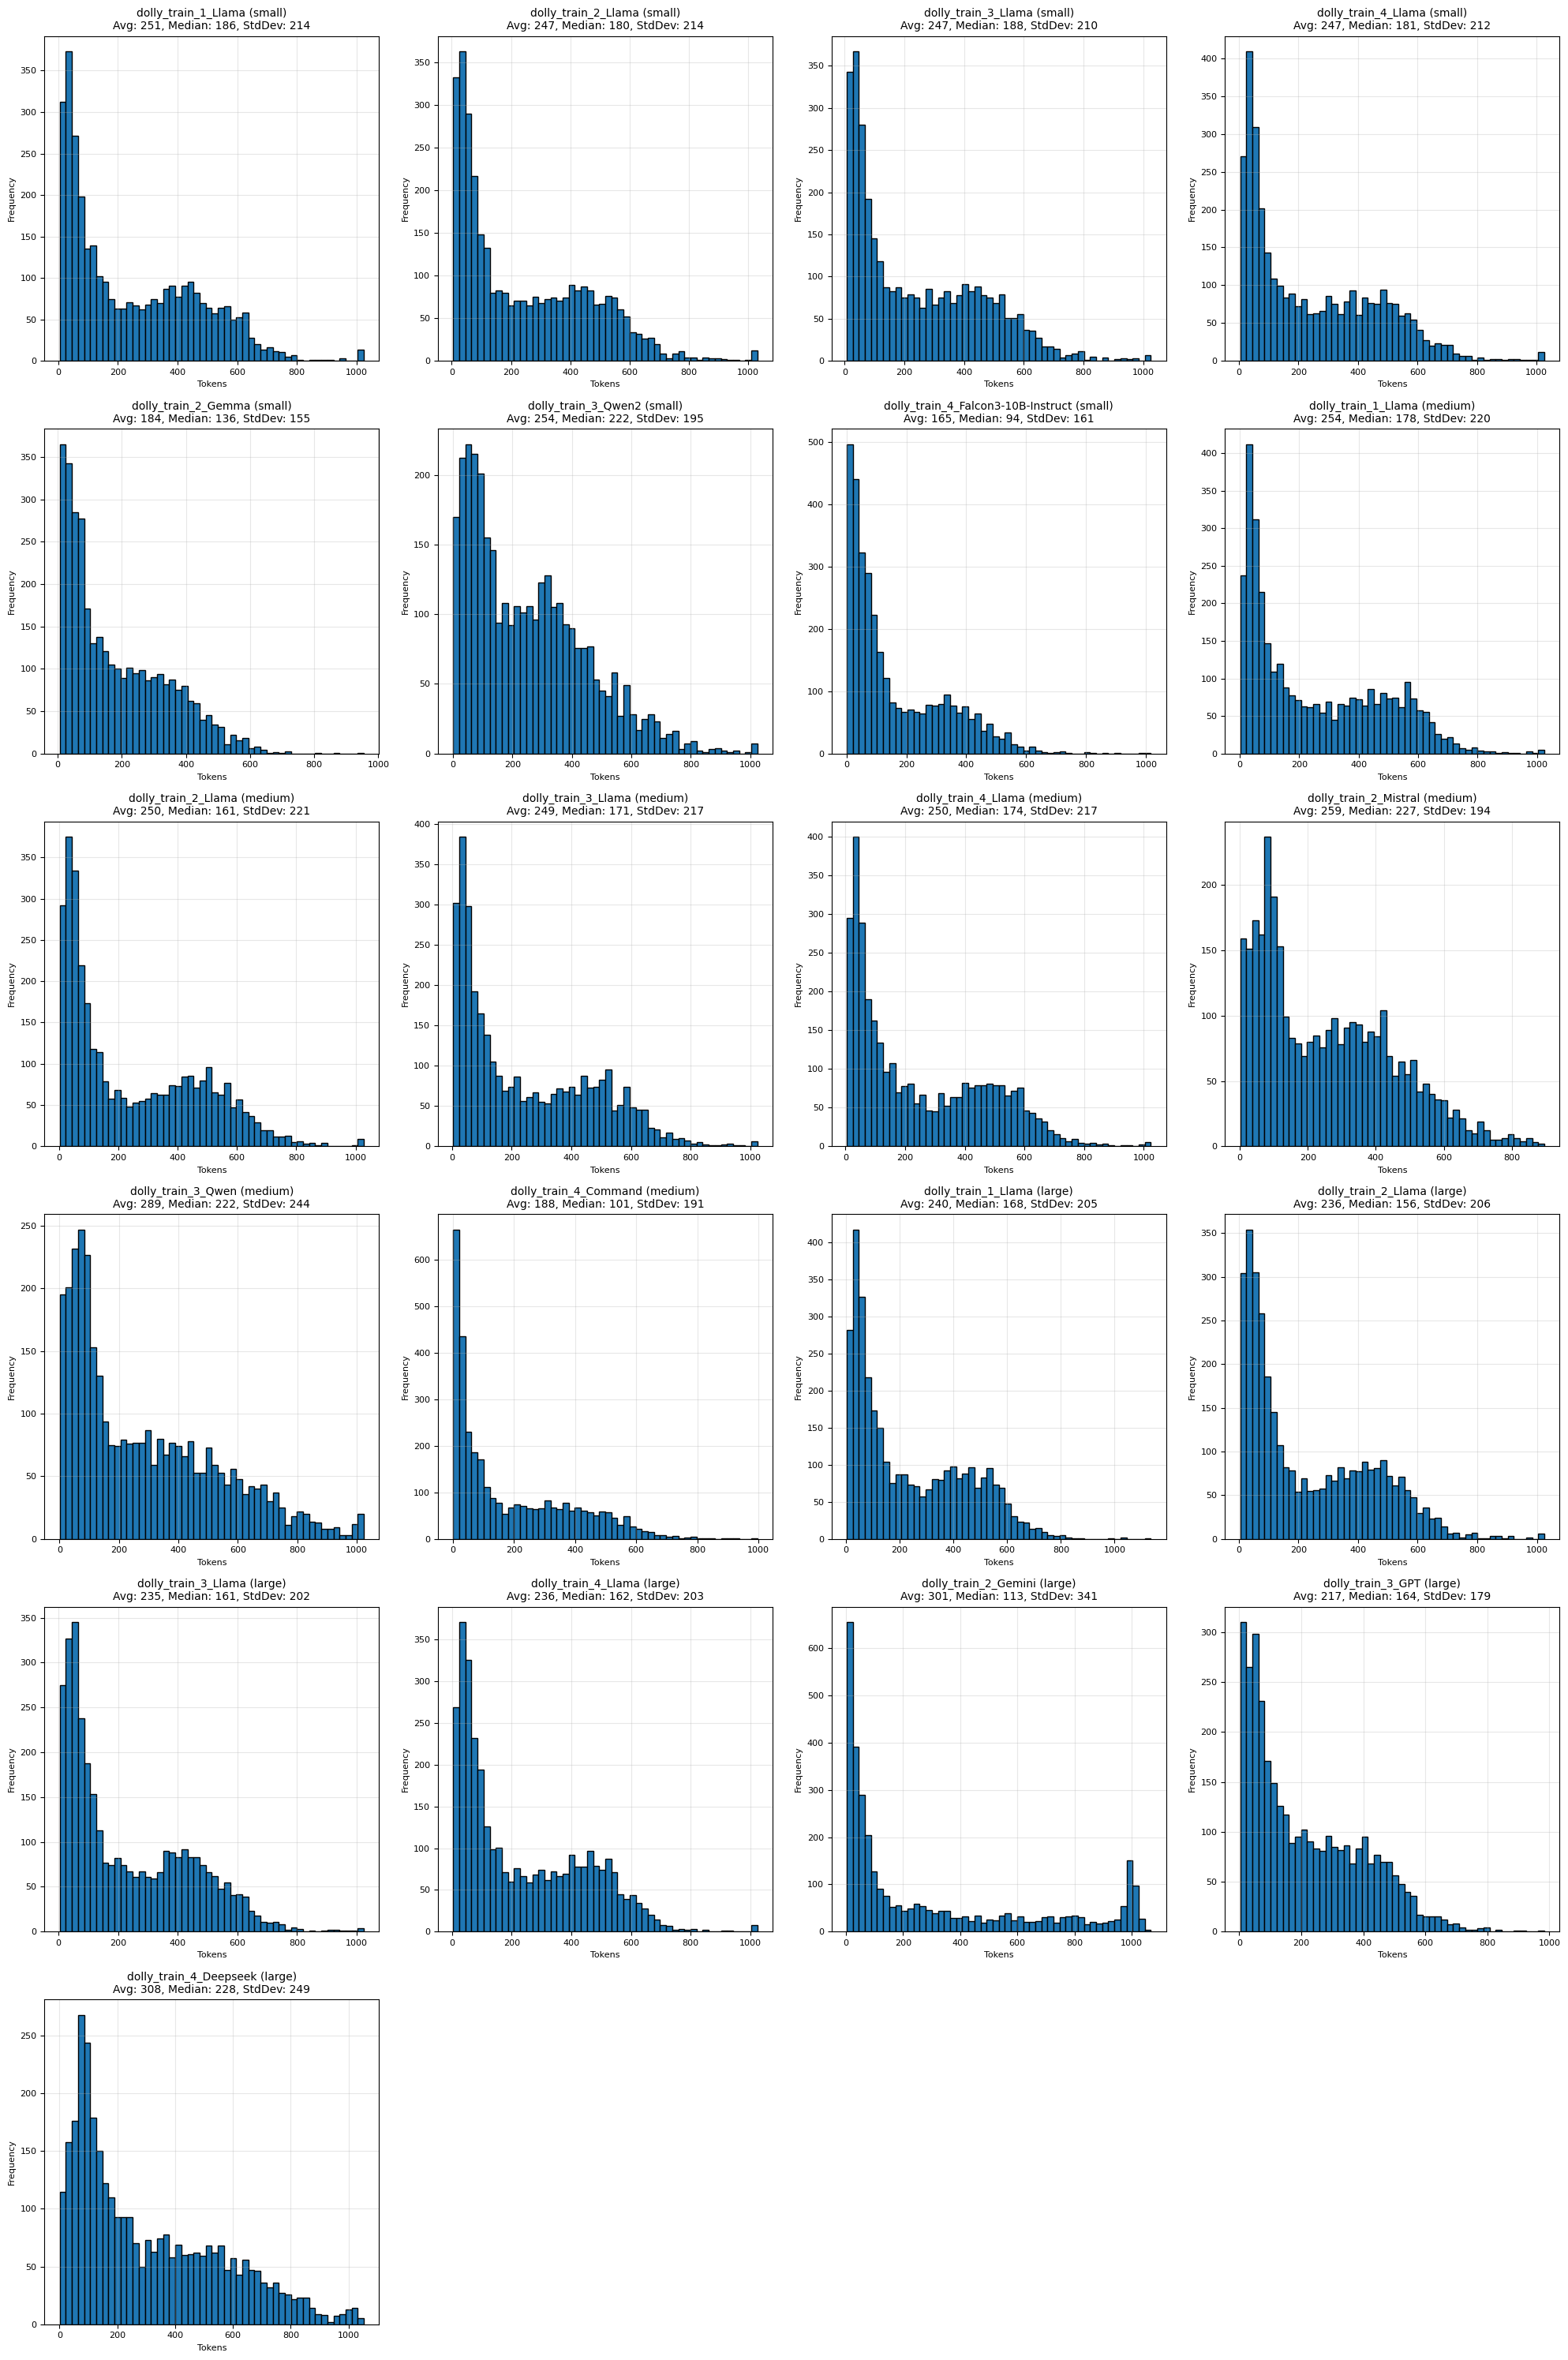

In [8]:
# Calculate grid dimensions based on number of files
num_files = len(data_paths)
num_cols = 4  # 4 columns
num_rows = (num_files + num_cols - 1) // num_cols  # Ceiling division

# Create subplot grid
fig = plt.figure(figsize=(20, 5*num_rows))
all_stats = []

model_sizes = ["small" for i in range(7)] + ["medium" for i in range(7)] + ["large" for i in range(8)]

# Create a DataFrame to store statistics
stats_df = pd.DataFrame(columns=['model_name', 'model_size', 'mean', 'median', 'max', 'min', 'std_dev'])

for idx, path in enumerate(data_paths):
    # Collect all response lengths
    response_lengths = []
    with open(path, 'r') as f:
        for line in f:
            data = json.loads(line)
            # Extract model name from path
            model_name = path.split('/')[-1].split('.')[0]
            response_key = [k for k in data.keys() if k.startswith('response_')][1]
            response = data[response_key]
            num_tokens = len(enc.encode(response))
            response_lengths.append(num_tokens)
    
    # Calculate statistics
    avg_len = sum(response_lengths)/len(response_lengths)
    median_len = sorted(response_lengths)[len(response_lengths)//2]
    max_len = max(response_lengths)
    min_len = min(response_lengths)
    std_dev = np.std(response_lengths)
    
    # Add to DataFrame
    stats_df = pd.concat([stats_df, pd.DataFrame({
        'model_name': [model_name],
        'model_size': [model_sizes[idx]],
        'mean': [avg_len],
        'median': [median_len],
        'max': [max_len],
        'min': [min_len],
        'std_dev': [std_dev]
    })], ignore_index=True)
    all_stats.append({
        'path': path,
        'avg': avg_len,
        'median': median_len,
        'max': max_len,
        'min': min_len,
        'std_dev': std_dev
    })
    
    
    # Create subplot
    plt.subplot(num_rows, num_cols, idx + 1)
    plt.hist(response_lengths, bins=50, edgecolor='black')
    plt.title(f'{model_name} ({model_sizes[idx]})\nAvg: {avg_len:.0f}, Median: {median_len:.0f}, StdDev: {std_dev:.0f}', fontsize=10)
    plt.xlabel('Tokens', fontsize=8)
    plt.ylabel('Frequency', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tick_params(axis='both', which='major', labelsize=8)

plt.tight_layout()
plt.show()



In [11]:
for idx, path in enumerate(human_paths):
    response_lengths = []
    with open(path, 'r') as f:
        for line in f:
            data = json.loads(line)
            # For human data, we want the response_human field
            response = data.get('response_human', '')
            num_tokens = len(enc.encode(response))
            response_lengths.append(num_tokens)
    
    # Calculate statistics
    avg_len = sum(response_lengths)/len(response_lengths)
    median_len = sorted(response_lengths)[len(response_lengths)//2]
    max_len = max(response_lengths)
    min_len = min(response_lengths)
    std_dev = np.std(response_lengths)
    
    # Extract version from path
    filename = path.split('/')[-1]
    version_match = re.search(r'dolly_train_(\d+)', filename)
    version = version_match.group(1) if version_match else "unknown"
    
    # Add to DataFrame
    stats_df = pd.concat([stats_df, pd.DataFrame({
        'model_name': [f"dolly_train_{version}_Human"],
        'model_size': ["human"],
        'mean': [avg_len],
        'median': [median_len],
        'max': [max_len],
        'min': [min_len],
        'std_dev': [std_dev]
    })], ignore_index=True)

stats_df.to_csv("../../Data/analysis/response_length/summary_table.csv", index=False)
stats_df.head(25)

,model_name,model_size,mean,median,max,min,std_dev
0,dolly_train_1_Llama,small,251.371336,186,1025,5,213.716565
1,dolly_train_2_Llama,small,247.181522,180,1031,5,214.154563
2,dolly_train_3_Llama,small,246.812259,188,1025,7,209.933000
3,dolly_train_4_Llama,small,246.563943,181,1026,4,212.170489
4,dolly_train_2_Gemma,small,184.107492,136,955,6,154.817646
5,dolly_train_3_Qwen2,small,253.871187,222,1024,1,195.066380
6,dolly_train_4_Falcon3-10B-Instruct,small,164.889480,94,1016,1,160.566267
7,dolly_train_1_Llama,medium,253.947587,178,1025,1,220.422248
8,dolly_train_2_Llama,medium,250.270654,161,1028,3,220.982158
9,dolly_train_3_Llama,medium,248.949956,171,1024,4,217.137422


# Box plots

In [23]:
statistics_llama_small = summary_statistics[(summary_statistics["model_name"].str.contains("Llama")) & (summary_statistics["model_size"] == "small")]
response_lengths_llama_small = []
for lengths_list in statistics_llama_small["response_lengths"]:
    response_lengths_llama_small.extend(lengths_list)

statistics_llama_medium = summary_statistics[(summary_statistics["model_name"].str.contains("Llama")) & (summary_statistics["model_size"] == "medium")]
response_lengths_llama_medium = []  
for lengths_list in statistics_llama_medium["response_lengths"]:
    response_lengths_llama_medium.extend(lengths_list)

statistics_llama_large = summary_statistics[(summary_statistics["model_name"].str.contains("Llama")) & (summary_statistics["model_size"] == "large")]
response_lengths_llama_large = []
for lengths_list in statistics_llama_large["response_lengths"]:
    response_lengths_llama_large.extend(lengths_list)

statistics_human = summary_statistics[summary_statistics["model_size"] == "human"]
response_lengths_human = []
for lengths_list in statistics_human["response_lengths"]:
    response_lengths_human.extend(lengths_list)


In [24]:
# Create a compact summary statistics dataframe with selected models
model_names_to_include = [
    "dolly_train_2_Gemma",
    "dolly_train_3_Qwen2",
    "dolly_train_4_Falcon3-10B-Instruct",
    "dolly_train_2_Mistral",
    "dolly_train_3_Qwen",
    "dolly_train_4_Command",
    "dolly_train_2_Gemini",
    "dolly_train_3_GPT",
    "dolly_train_4_Deepseek"
]

# Filter the summary statistics for the selected models
summary_statistics_compact = summary_statistics[summary_statistics["model_name"].isin(model_names_to_include)].copy()

# Add rows for the Llama models of different sizes and human responses
additional_rows = []

# Add Llama small
llama_small_stats = {
    "model_name": "Llama_small",
    "model_size": "small",
    "mean": np.mean(response_lengths_llama_small),
    "median": np.median(response_lengths_llama_small),
    "max": np.max(response_lengths_llama_small),
    "min": np.min(response_lengths_llama_small),
    "std_dev": np.std(response_lengths_llama_small),
    "response_lengths": response_lengths_llama_small
}
additional_rows.append(llama_small_stats)

# Add Llama medium
llama_medium_stats = {
    "model_name": "Llama_medium",
    "model_size": "medium",
    "mean": np.mean(response_lengths_llama_medium),
    "median": np.median(response_lengths_llama_medium),
    "max": np.max(response_lengths_llama_medium),
    "min": np.min(response_lengths_llama_medium),
    "std_dev": np.std(response_lengths_llama_medium),
    "response_lengths": response_lengths_llama_medium
}
additional_rows.append(llama_medium_stats)

# Add Llama large
llama_large_stats = {
    "model_name": "Llama_large",
    "model_size": "large",
    "mean": np.mean(response_lengths_llama_large),
    "median": np.median(response_lengths_llama_large),
    "max": np.max(response_lengths_llama_large),
    "min": np.min(response_lengths_llama_large),
    "std_dev": np.std(response_lengths_llama_large),
    "response_lengths": response_lengths_llama_large
}
additional_rows.append(llama_large_stats)

# Add Human responses
human_stats = {
    "model_name": "Human",
    "model_size": "human",
    "mean": np.mean(response_lengths_human),
    "median": np.median(response_lengths_human),
    "max": np.max(response_lengths_human),
    "min": np.min(response_lengths_human),
    "std_dev": np.std(response_lengths_human),
    "response_lengths": response_lengths_human
}
additional_rows.append(human_stats)

# Add the additional rows to the compact summary statistics
summary_statistics_compact = pd.concat([
    summary_statistics_compact,
    pd.DataFrame(additional_rows)
], ignore_index=True)

# Display the compact summary statistics
summary_statistics_compact.head(len(summary_statistics_compact))


,model_name,model_size,mean,median,max,min,std_dev,response_lengths
0,dolly_train_2_Gemma,small,184.107492,136,955,6,154.817646,"[299, 76, 116, 37, 212, 314, 12, 87, 111, 456,..."
1,dolly_train_3_Qwen2,small,253.871187,222,1024,1,195.066380,"[189, 470, 97, 23, 580, 40, 376, 109, 224, 361..."
2,dolly_train_4_Falcon3-10B-Instruct,small,164.889480,94,1016,1,160.566267,"[20, 168, 32, 52, 71, 110, 60, 246, 121, 135, ..."
3,dolly_train_2_Mistral,medium,258.716316,227,896,1,194.226291,"[415, 73, 272, 98, 406, 313, 26, 193, 142, 379..."
4,dolly_train_3_Qwen,medium,288.858454,222,1024,1,243.954980,"[67, 514, 95, 25, 706, 41, 362, 68, 287, 385, ..."
5,dolly_train_4_Command,medium,188.246596,101,997,1,190.717819,"[43, 290, 25, 113, 83, 118, 87, 312, 232, 91, ..."
6,dolly_train_2_Gemini,large,300.876258,113,1067,3,341.270528,"[291, 83, 119, 12, 715, 468, 19, 142, 112, 996..."
7,dolly_train_3_GPT,large,216.505924,164,984,3,178.793133,"[79, 473, 93, 22, 540, 37, 288, 72, 138, 226, ..."
8,dolly_train_4_Deepseek,large,307.770870,228,1053,1,248.773307,"[58, 265, 118, 144, 104, 173, 339, 451, 244, 2..."
9,Llama_small,small,247.982160,183.0,1031,4,212.509173,"[260, 48, 315, 34, 486, 131, 26, 237, 295, 649..."


In [25]:
summary_statistics_compact.to_pickle("../../Data/analysis/response_length/summary_table_with_response_lengths_compact.pkl")

In [26]:
summary_statistics_compact.head(25)

# Clean up model names by removing "dolly_train_x_" prefix
summary_statistics_compact['model_name'] = summary_statistics_compact['model_name'].apply(
    lambda x: x.split('dolly_train_')[1].split('_')[1] if 'dolly_train_' in x else x
)



# Display the updated summary statistics
summary_statistics_compact.head(25)


,model_name,model_size,mean,median,max,min,std_dev,response_lengths
0,Gemma,small,184.107492,136,955,6,154.817646,"[299, 76, 116, 37, 212, 314, 12, 87, 111, 456,..."
1,Qwen2,small,253.871187,222,1024,1,195.066380,"[189, 470, 97, 23, 580, 40, 376, 109, 224, 361..."
2,Falcon3-10B-Instruct,small,164.889480,94,1016,1,160.566267,"[20, 168, 32, 52, 71, 110, 60, 246, 121, 135, ..."
3,Mistral,medium,258.716316,227,896,1,194.226291,"[415, 73, 272, 98, 406, 313, 26, 193, 142, 379..."
4,Qwen,medium,288.858454,222,1024,1,243.954980,"[67, 514, 95, 25, 706, 41, 362, 68, 287, 385, ..."
5,Command,medium,188.246596,101,997,1,190.717819,"[43, 290, 25, 113, 83, 118, 87, 312, 232, 91, ..."
6,Gemini,large,300.876258,113,1067,3,341.270528,"[291, 83, 119, 12, 715, 468, 19, 142, 112, 996..."
7,GPT,large,216.505924,164,984,3,178.793133,"[79, 473, 93, 22, 540, 37, 288, 72, 138, 226, ..."
8,Deepseek,large,307.770870,228,1053,1,248.773307,"[58, 265, 118, 144, 104, 173, 339, 451, 244, 2..."
9,Llama_small,small,247.982160,183.0,1031,4,212.509173,"[260, 48, 315, 34, 486, 131, 26, 237, 295, 649..."


In [27]:
# Reorder the dataframe to put Llama models at the beginning of their respective size groups
# First, create a new column for sorting
summary_statistics_compact['sort_key'] = summary_statistics_compact.apply(
    lambda row: (
        # Order by model_size first (small, medium, large, human)
        {'small': 0, 'medium': 1, 'large': 2, 'human': 3}.get(row['model_size'], 4),
        # Then within each size group, put Llama first
        0 if row['model_name'] == 'Llama' else 1,
        # Then use the original index for stable sorting
        row.name
    ), 
    axis=1
)

# Sort by the new column
summary_statistics_compact = summary_statistics_compact.sort_values('sort_key')

# Drop the temporary sorting column
summary_statistics_compact = summary_statistics_compact.drop('sort_key', axis=1)

# Reset the index
summary_statistics_compact = summary_statistics_compact.reset_index(drop=True)

# Display the reordered dataframe
summary_statistics_compact.head(len(summary_statistics_compact))


,model_name,model_size,mean,median,max,min,std_dev,response_lengths
0,Gemma,small,184.107492,136,955,6,154.817646,"[299, 76, 116, 37, 212, 314, 12, 87, 111, 456,..."
1,Qwen2,small,253.871187,222,1024,1,195.066380,"[189, 470, 97, 23, 580, 40, 376, 109, 224, 361..."
2,Falcon3-10B-Instruct,small,164.889480,94,1016,1,160.566267,"[20, 168, 32, 52, 71, 110, 60, 246, 121, 135, ..."
3,Llama_small,small,247.982160,183.0,1031,4,212.509173,"[260, 48, 315, 34, 486, 131, 26, 237, 295, 649..."
4,Mistral,medium,258.716316,227,896,1,194.226291,"[415, 73, 272, 98, 406, 313, 26, 193, 142, 379..."
5,Qwen,medium,288.858454,222,1024,1,243.954980,"[67, 514, 95, 25, 706, 41, 362, 68, 287, 385, ..."
6,Command,medium,188.246596,101,997,1,190.717819,"[43, 290, 25, 113, 83, 118, 87, 312, 232, 91, ..."
7,Llama_medium,medium,250.714191,172.0,1028,1,218.802154,"[208, 18, 292, 12, 622, 111, 30, 313, 432, 702..."
8,Gemini,large,300.876258,113,1067,3,341.270528,"[291, 83, 119, 12, 715, 468, 19, 142, 112, 996..."
9,GPT,large,216.505924,164,984,3,178.793133,"[79, 473, 93, 22, 540, 37, 288, 72, 138, 226, ..."


In [28]:
# Clean up Llama model names by removing size suffixes (_small, _medium, _large)
summary_statistics_compact['model_name'] = summary_statistics_compact['model_name'].apply(
    lambda x: 'Llama' if x.startswith('Llama_') else x
)

# Display the updated summary statistics with cleaned Llama names
summary_statistics_compact.head(len(summary_statistics_compact))


,model_name,model_size,mean,median,max,min,std_dev,response_lengths
0,Gemma,small,184.107492,136,955,6,154.817646,"[299, 76, 116, 37, 212, 314, 12, 87, 111, 456,..."
1,Qwen2,small,253.871187,222,1024,1,195.066380,"[189, 470, 97, 23, 580, 40, 376, 109, 224, 361..."
2,Falcon3-10B-Instruct,small,164.889480,94,1016,1,160.566267,"[20, 168, 32, 52, 71, 110, 60, 246, 121, 135, ..."
3,Llama,small,247.982160,183.0,1031,4,212.509173,"[260, 48, 315, 34, 486, 131, 26, 237, 295, 649..."
4,Mistral,medium,258.716316,227,896,1,194.226291,"[415, 73, 272, 98, 406, 313, 26, 193, 142, 379..."
5,Qwen,medium,288.858454,222,1024,1,243.954980,"[67, 514, 95, 25, 706, 41, 362, 68, 287, 385, ..."
6,Command,medium,188.246596,101,997,1,190.717819,"[43, 290, 25, 113, 83, 118, 87, 312, 232, 91, ..."
7,Llama,medium,250.714191,172.0,1028,1,218.802154,"[208, 18, 292, 12, 622, 111, 30, 313, 432, 702..."
8,Gemini,large,300.876258,113,1067,3,341.270528,"[291, 83, 119, 12, 715, 468, 19, 142, 112, 996..."
9,GPT,large,216.505924,164,984,3,178.793133,"[79, 473, 93, 22, 540, 37, 288, 72, 138, 226, ..."


In [29]:
# Move the human dataset row to the beginning of the dataframe
# First, identify the human row
human_row = summary_statistics_compact[summary_statistics_compact['model_size'] == 'human']

# Remove the human row from the dataframe
summary_statistics_compact = summary_statistics_compact[summary_statistics_compact['model_size'] != 'human']

# Concatenate the human row at the beginning and reset the index
summary_statistics_compact = pd.concat([human_row, summary_statistics_compact]).reset_index(drop=True)

# Display the updated dataframe with human row at the beginning
summary_statistics_compact.head(len(summary_statistics_compact))




,model_name,model_size,mean,median,max,min,std_dev,response_lengths
0,Human,human,78.523355,44.0,5262,1,128.687348,"[25, 1267, 267, 75, 86, 67, 27, 47, 53, 67, 19..."
1,Gemma,small,184.107492,136,955,6,154.817646,"[299, 76, 116, 37, 212, 314, 12, 87, 111, 456,..."
2,Qwen2,small,253.871187,222,1024,1,195.066380,"[189, 470, 97, 23, 580, 40, 376, 109, 224, 361..."
3,Falcon3-10B-Instruct,small,164.889480,94,1016,1,160.566267,"[20, 168, 32, 52, 71, 110, 60, 246, 121, 135, ..."
4,Llama,small,247.982160,183.0,1031,4,212.509173,"[260, 48, 315, 34, 486, 131, 26, 237, 295, 649..."
5,Mistral,medium,258.716316,227,896,1,194.226291,"[415, 73, 272, 98, 406, 313, 26, 193, 142, 379..."
6,Qwen,medium,288.858454,222,1024,1,243.954980,"[67, 514, 95, 25, 706, 41, 362, 68, 287, 385, ..."
7,Command,medium,188.246596,101,997,1,190.717819,"[43, 290, 25, 113, 83, 118, 87, 312, 232, 91, ..."
8,Llama,medium,250.714191,172.0,1028,1,218.802154,"[208, 18, 292, 12, 622, 111, 30, 313, 432, 702..."
9,Gemini,large,300.876258,113,1067,3,341.270528,"[291, 83, 119, 12, 715, 468, 19, 142, 112, 996..."


In [30]:
summary_statistics_compact.to_pickle("../../Data/analysis/response_length/summary_table_with_response_lengths_compact_v2.pkl")

In [31]:
# Rename specific model names for better readability
summary_statistics_compact['model_name'] = summary_statistics_compact['model_name'].replace({
    'Falcon3-10B-Instruct': 'Falcon',
    'Qwen2': 'Qwen'
})

# Display the updated dataframe with renamed models
summary_statistics_compact.head(len(summary_statistics_compact))
summary_statistics_compact.to_pickle("../../Data/analysis/response_length/summary_table_with_response_lengths_compact_v3.pkl")


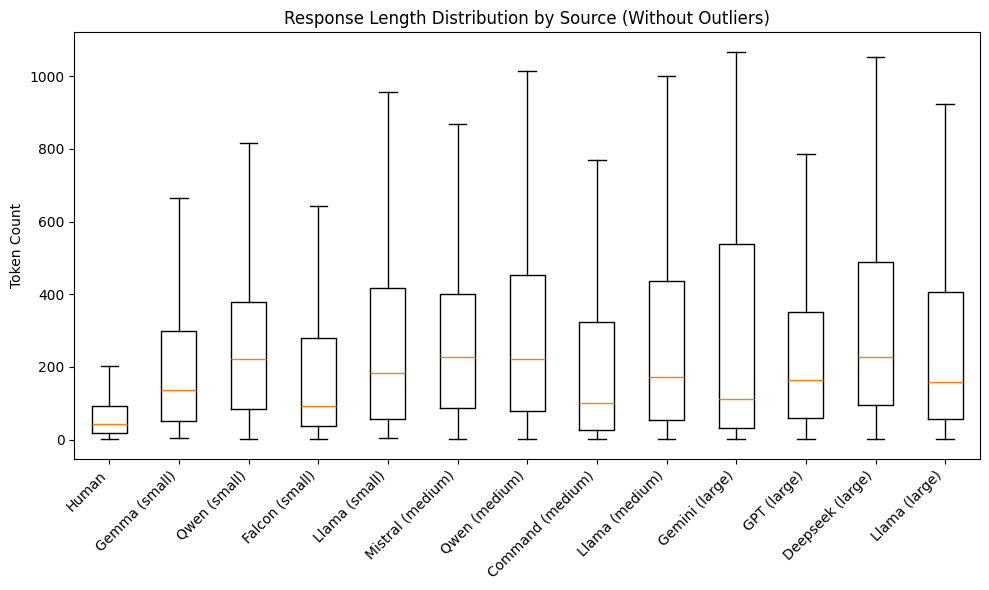

In [33]:
# Get response lengths from summary statistics
response_lengths = summary_statistics_compact["response_lengths"]

# Create labels with model name and size in brackets
model_labels = [f"Human" if row['model_name'].lower() == 'human' else f"{row['model_name']} ({row['model_size']})" 
                for _, row in summary_statistics_compact.iterrows()]

# Create a boxplot with model names as labels
plt.figure(figsize=(10, 6))
plt.boxplot(response_lengths, tick_labels=model_labels, vert=True, showfliers=False)
plt.title("Response Length Distribution by Source (Without Outliers)")
plt.ylabel("Token Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

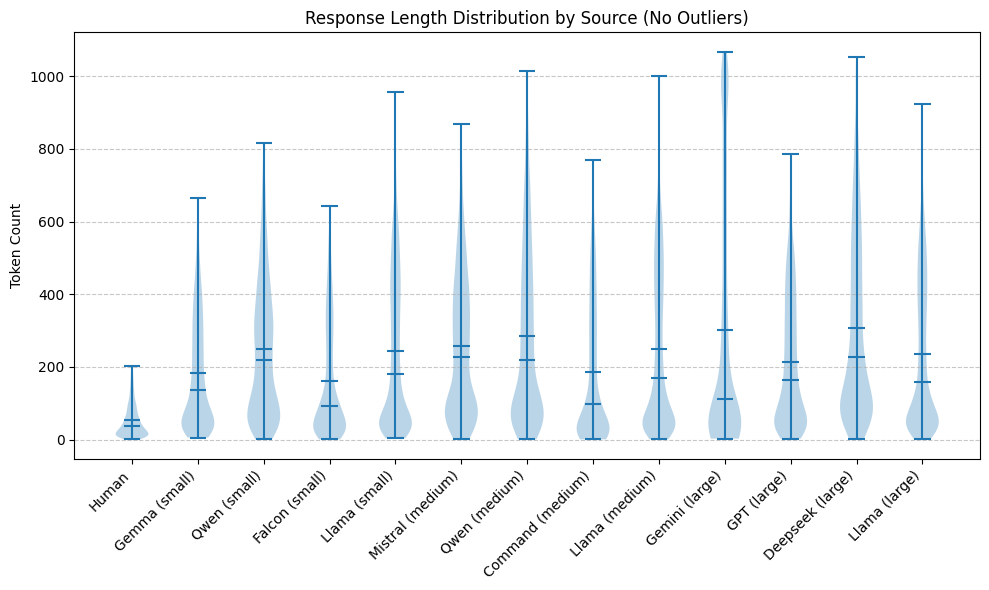

In [34]:
# Get response lengths from summary statistics
response_lengths = summary_statistics_compact["response_lengths"]

# Create a violin plot with model names as labels, excluding outliers
plt.figure(figsize=(10, 6))

# Calculate quartiles for each dataset to determine outlier thresholds
cleaned_response_lengths = []
for lengths in response_lengths:
    q1 = np.percentile(lengths, 25)
    q3 = np.percentile(lengths, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Filter out outliers
    filtered_lengths = [x for x in lengths if lower_bound <= x <= upper_bound]
    cleaned_response_lengths.append(filtered_lengths)

plt.violinplot(cleaned_response_lengths, showmeans=True, showmedians=True)
plt.xticks(range(1, len(model_labels) + 1), model_labels, rotation=45, ha='right')
plt.title("Response Length Distribution by Source (No Outliers)")
plt.ylabel("Token Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Grouping by dolly version

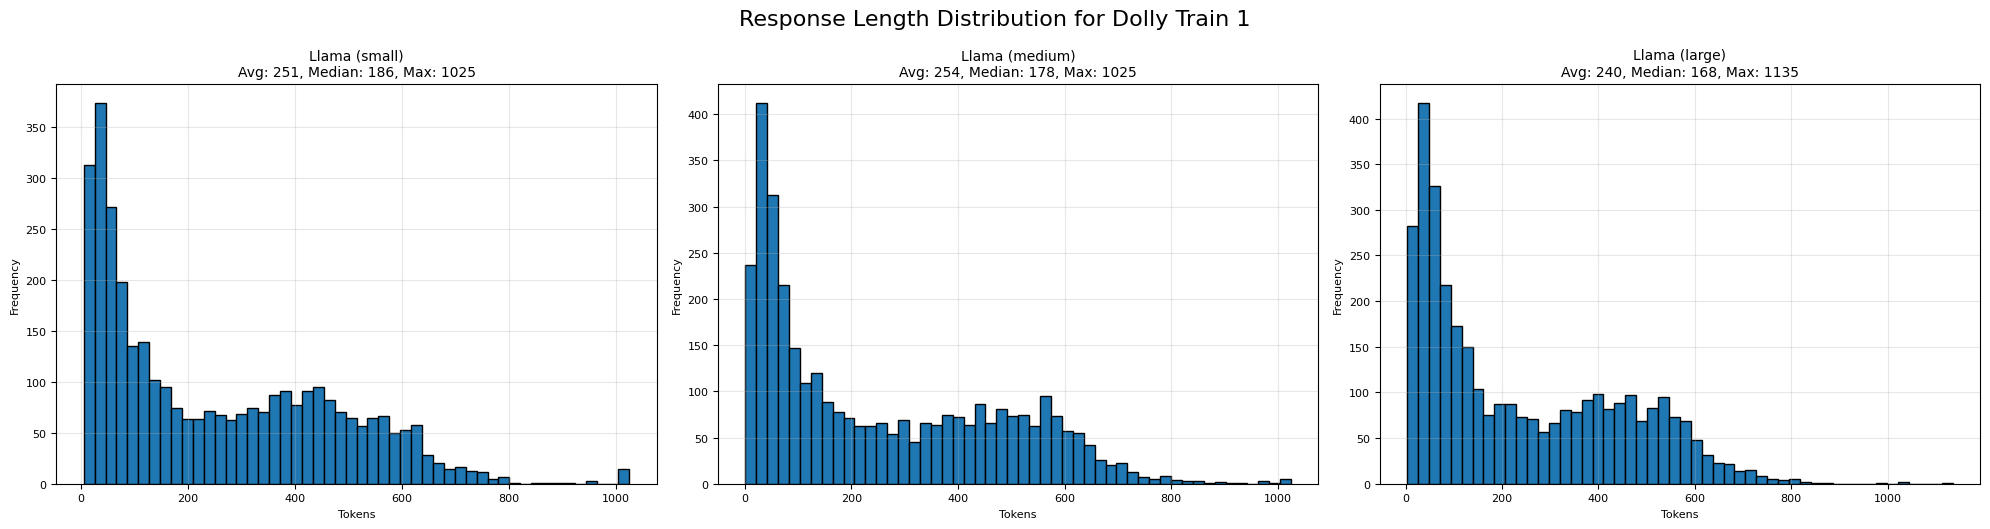

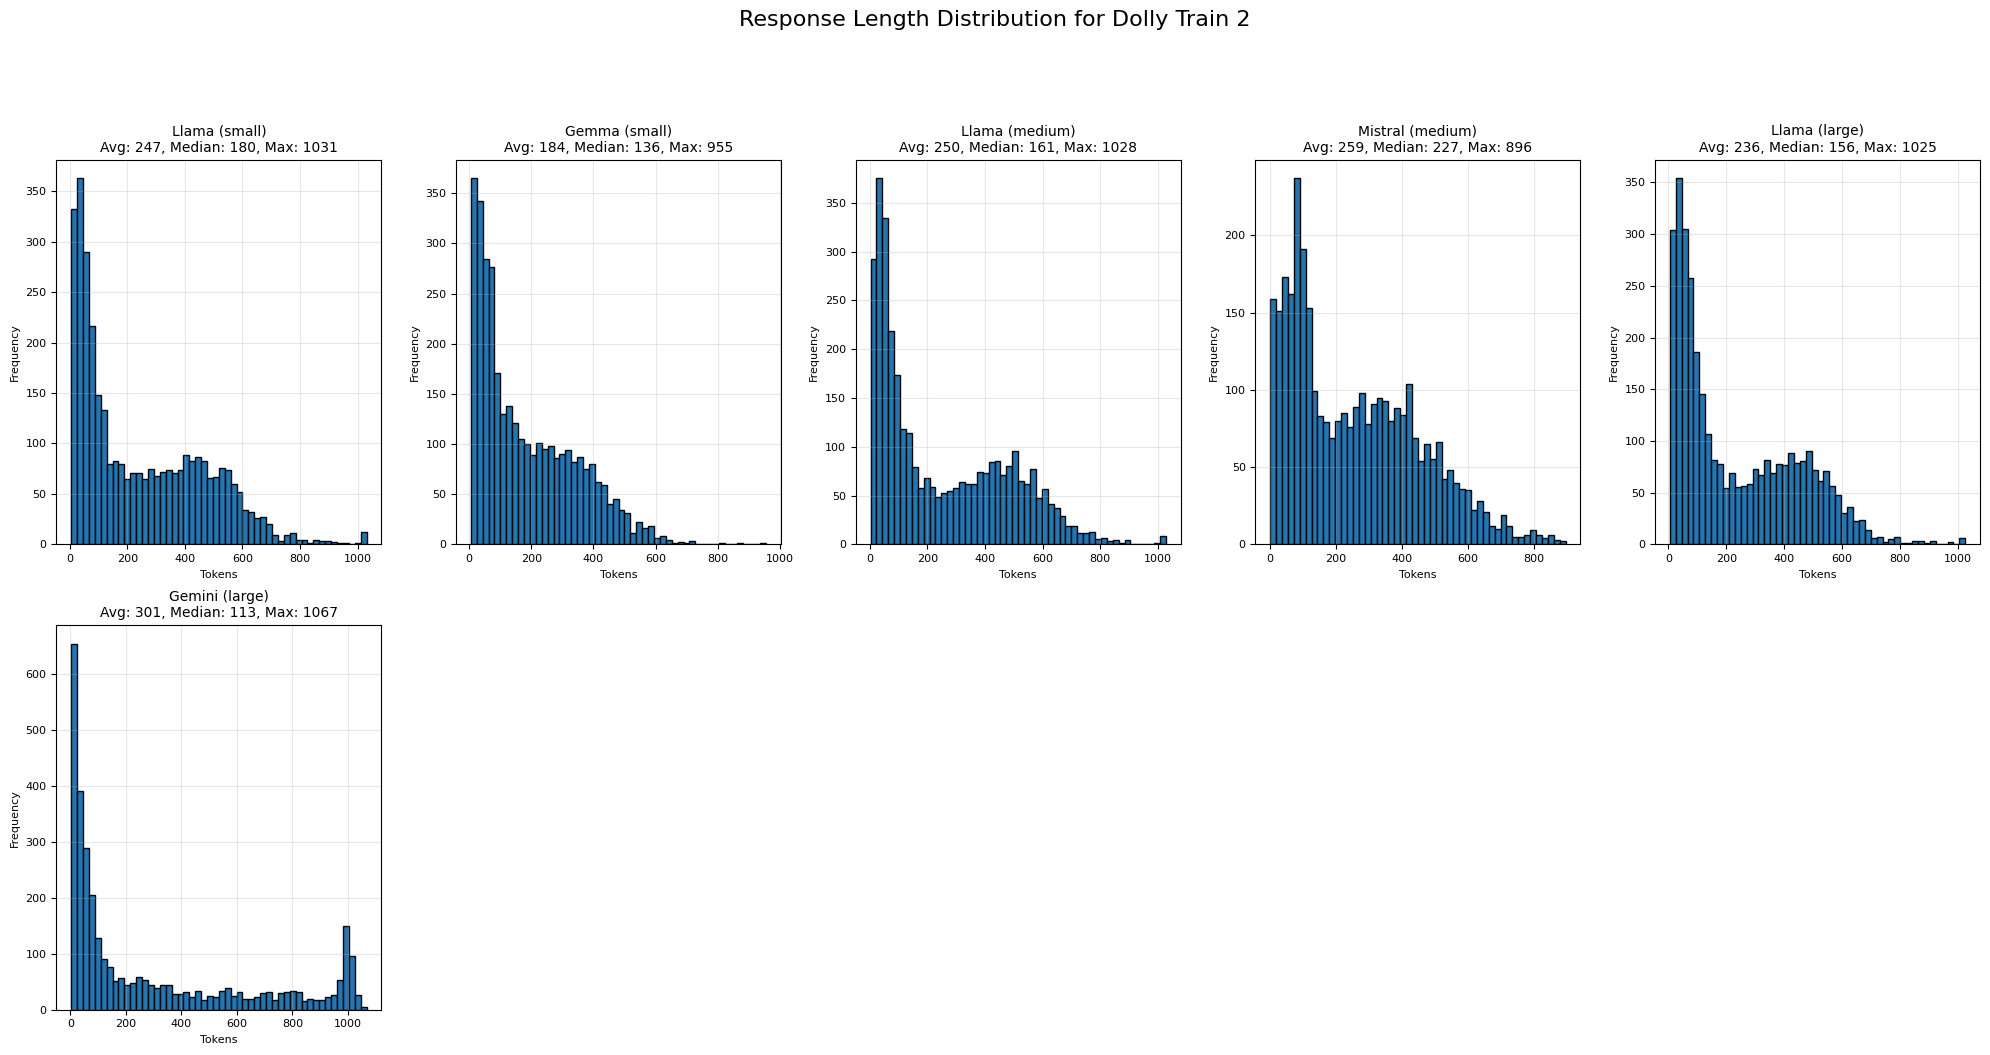

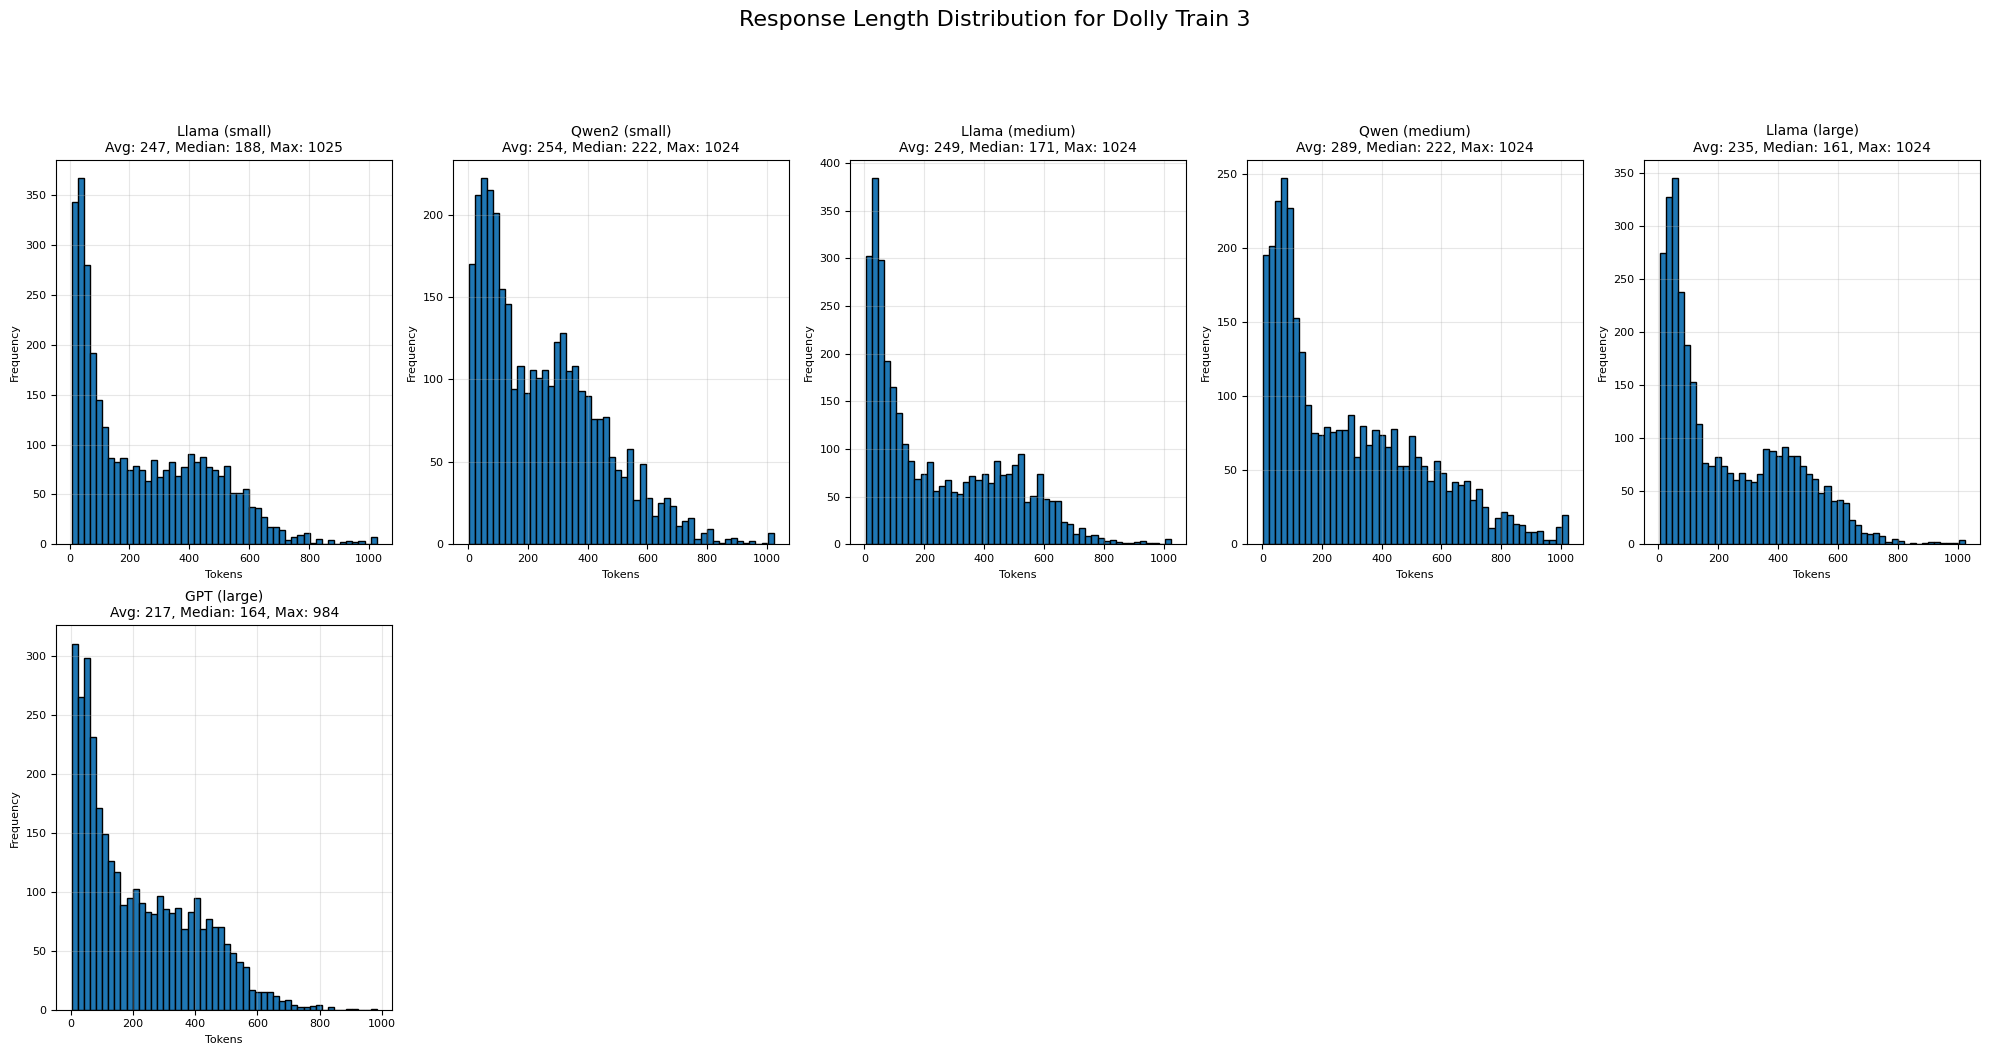

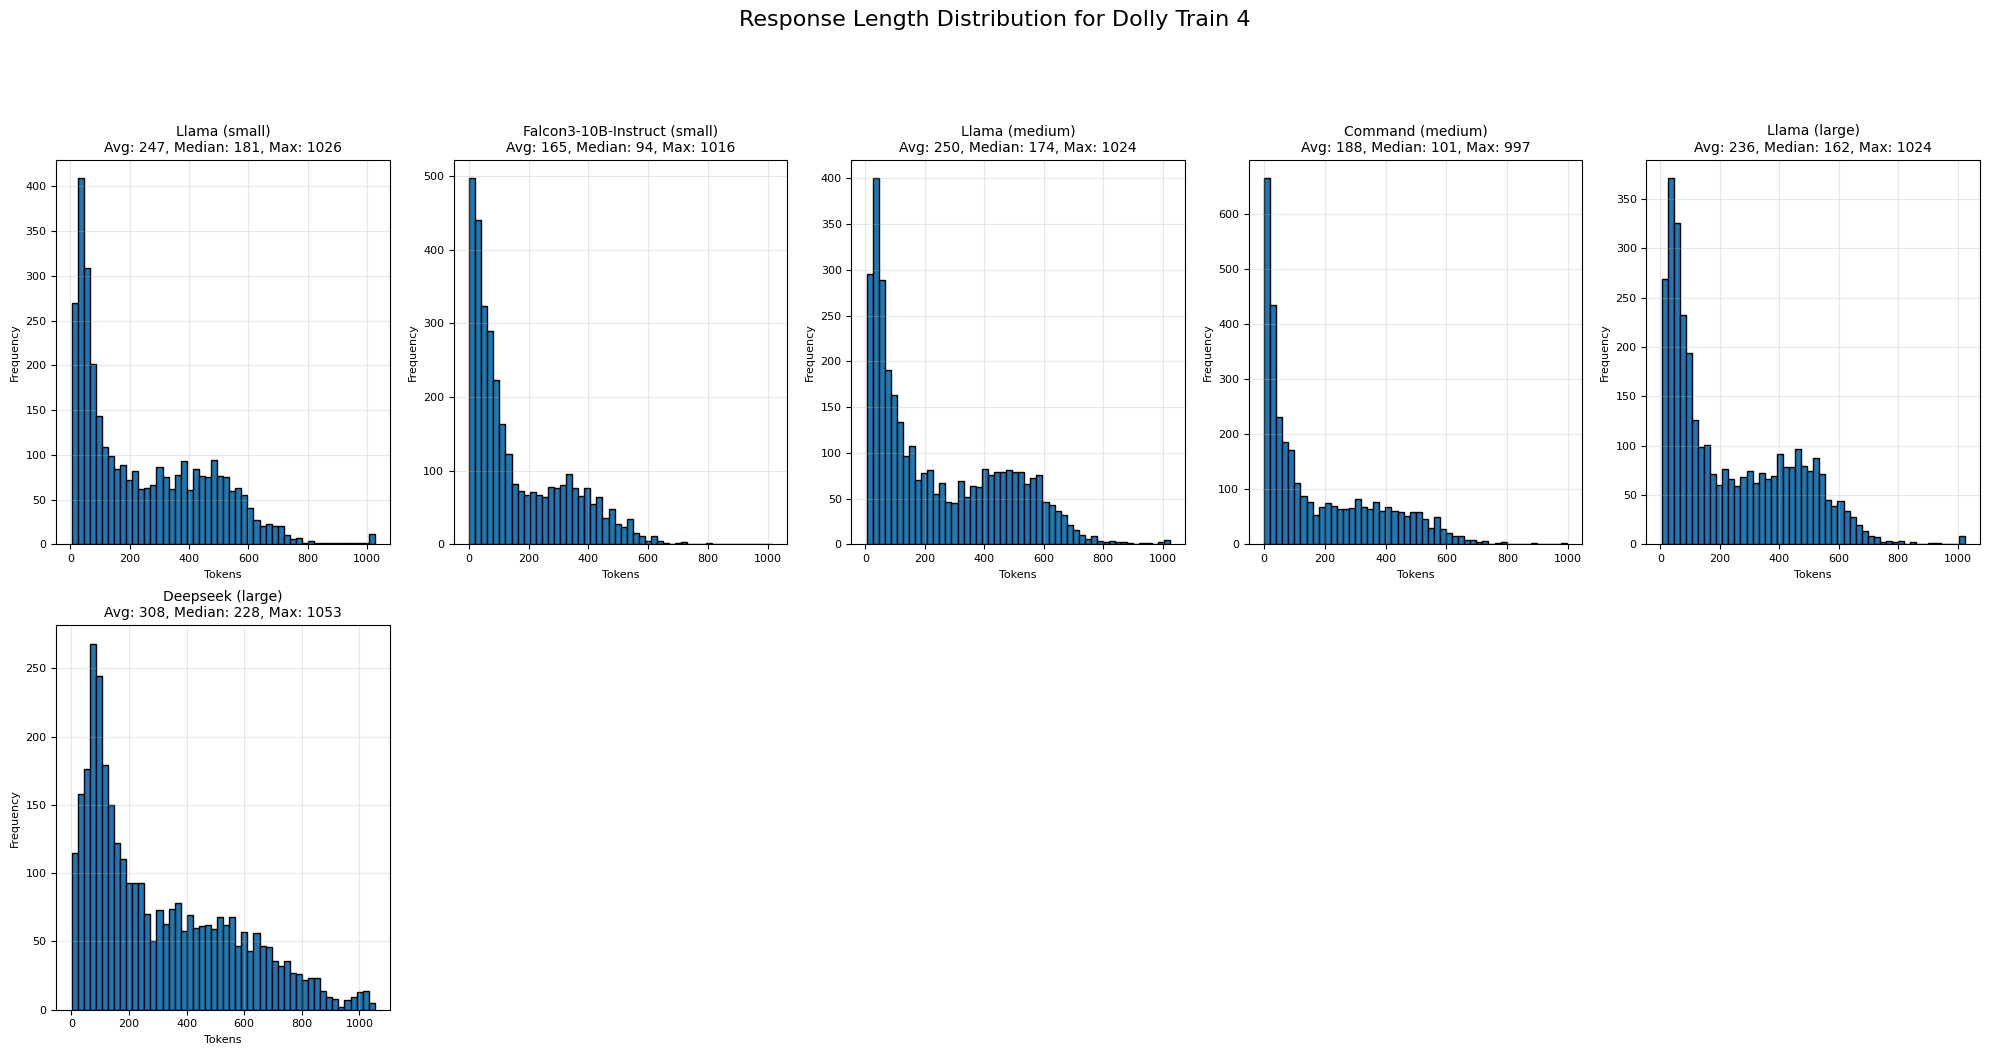

In [35]:
# Group data paths by dolly version


dolly_versions = {}
for path in data_paths:
    # Extract dolly version from the path
    filename = path.split('/')[-1]
    if 'dolly_train_' in filename:
        # Extract the version number
        version_match = re.search(r'dolly_train_(\d+)', filename)
        if version_match:
            version = int(version_match.group(1))
            if version not in dolly_versions:
                dolly_versions[version] = []
            dolly_versions[version].append(path)

# Create separate figures for each dolly version
for version, paths in dolly_versions.items():
    # Calculate grid dimensions based on number of models for this version
    num_models = len(paths)
    num_cols = min(5, num_models)
    num_rows = (num_models + num_cols - 1) // num_cols  # Ceiling division
    
    # Create figure with appropriate size
    plt.figure(figsize=(20, 5 * num_rows))
    
    # Plot histograms for each model in this version
    for idx, path in enumerate(paths):
        response_lengths = []
        with open(path, 'r') as f:
            for line in f:
                data = json.loads(line)
                response_key = [k for k in data.keys() if k.startswith('response_')][1]
                response = data[response_key]
                num_tokens = len(enc.encode(response))
                response_lengths.append(num_tokens)
        
        # Calculate statistics
        avg_len = sum(response_lengths)/len(response_lengths)
        median_len = sorted(response_lengths)[len(response_lengths)//2]
        max_len = max(response_lengths)
        min_len = min(response_lengths)
        
        # Extract model name from path
        model_name = path.split('/')[-1].split('.')[0]
        if 'dolly_train_' in model_name:
            # Extract only the model name part after dolly_train_X_
            model_name = model_name.split('dolly_train_')[1]
            # Remove the version number and underscore
            model_name = '_'.join(model_name.split('_')[1:])
        model_size = model_sizes[data_paths.index(path)]
        
        # Create subplot
        plt.subplot(num_rows, num_cols, idx + 1)
        plt.hist(response_lengths, bins=50, edgecolor='black')
        plt.title(f'{model_name} ({model_size})\nAvg: {avg_len:.0f}, Median: {median_len:.0f}, Max: {max_len}', fontsize=10)
        plt.xlabel('Tokens', fontsize=8)
        plt.ylabel('Frequency', fontsize=8)
        plt.grid(True, alpha=0.3)
        #plt.xlim(0, 1000)
        plt.tick_params(axis='both', which='major', labelsize=8)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  # Increase space at the top for the suptitle
    plt.suptitle(f'Response Length Distribution for Dolly Train {version}', fontsize=16, y=1.05)  # Position suptitle higher
    plt.show()


# Combined histograms

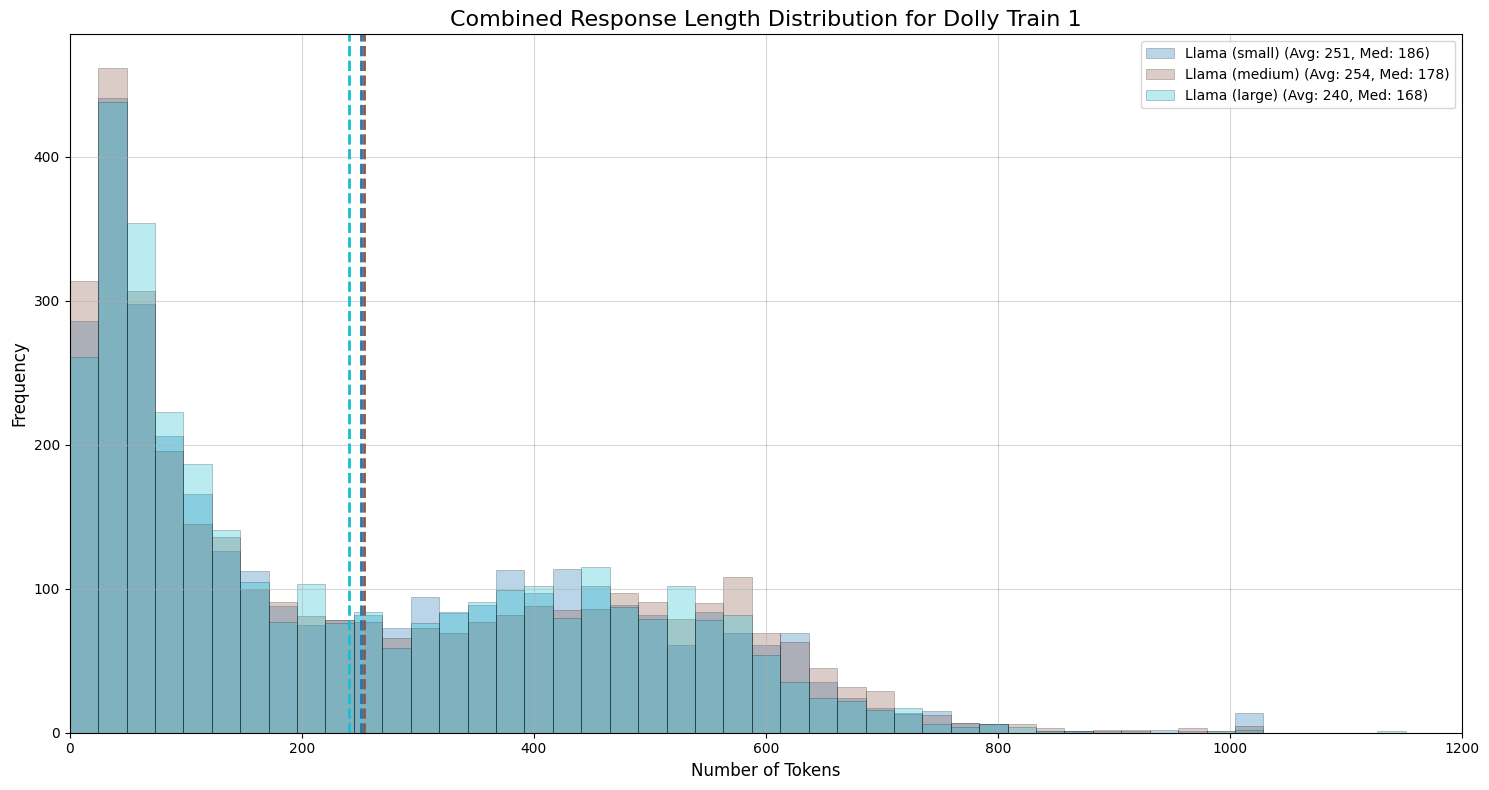

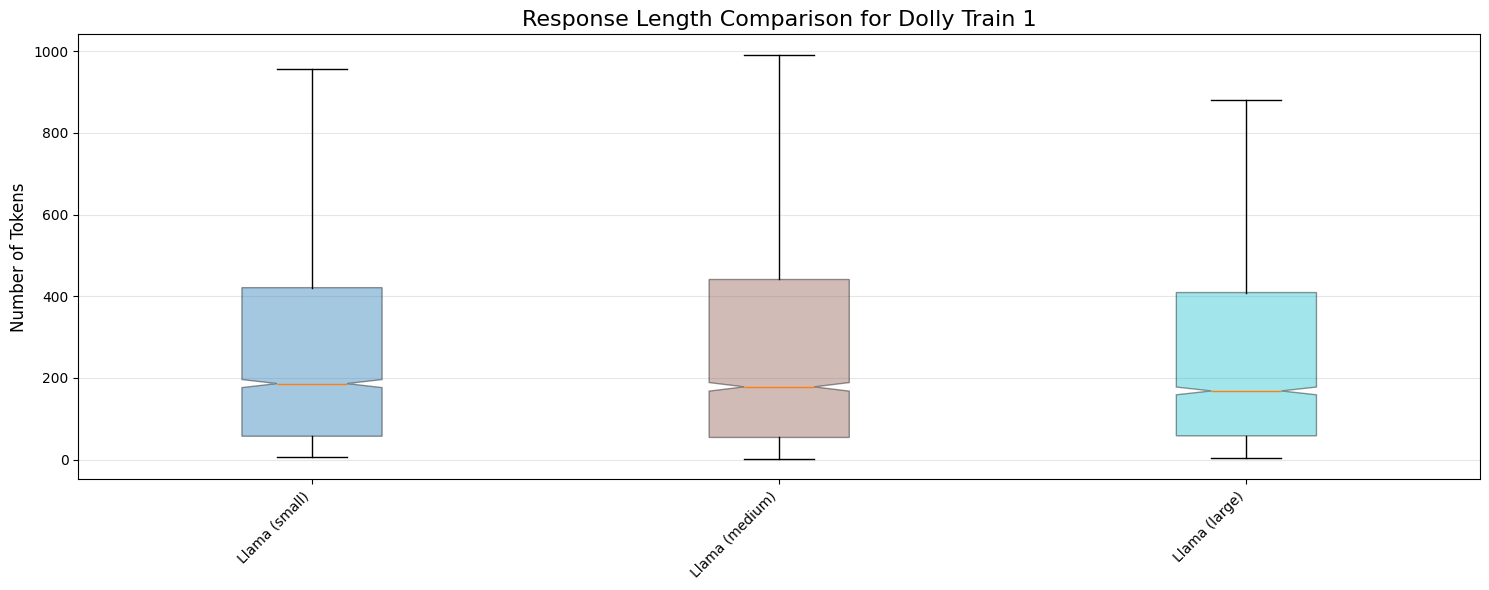

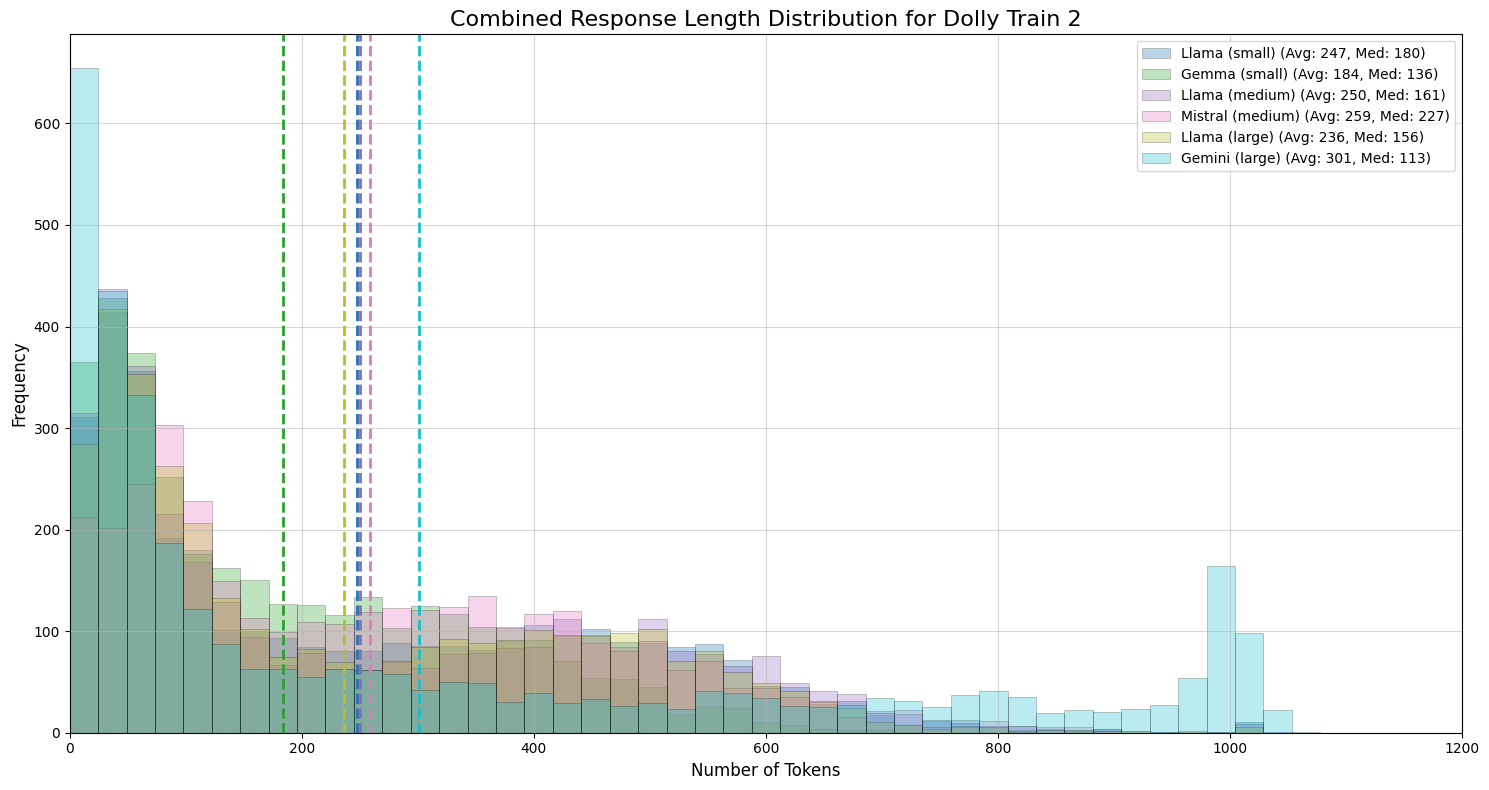

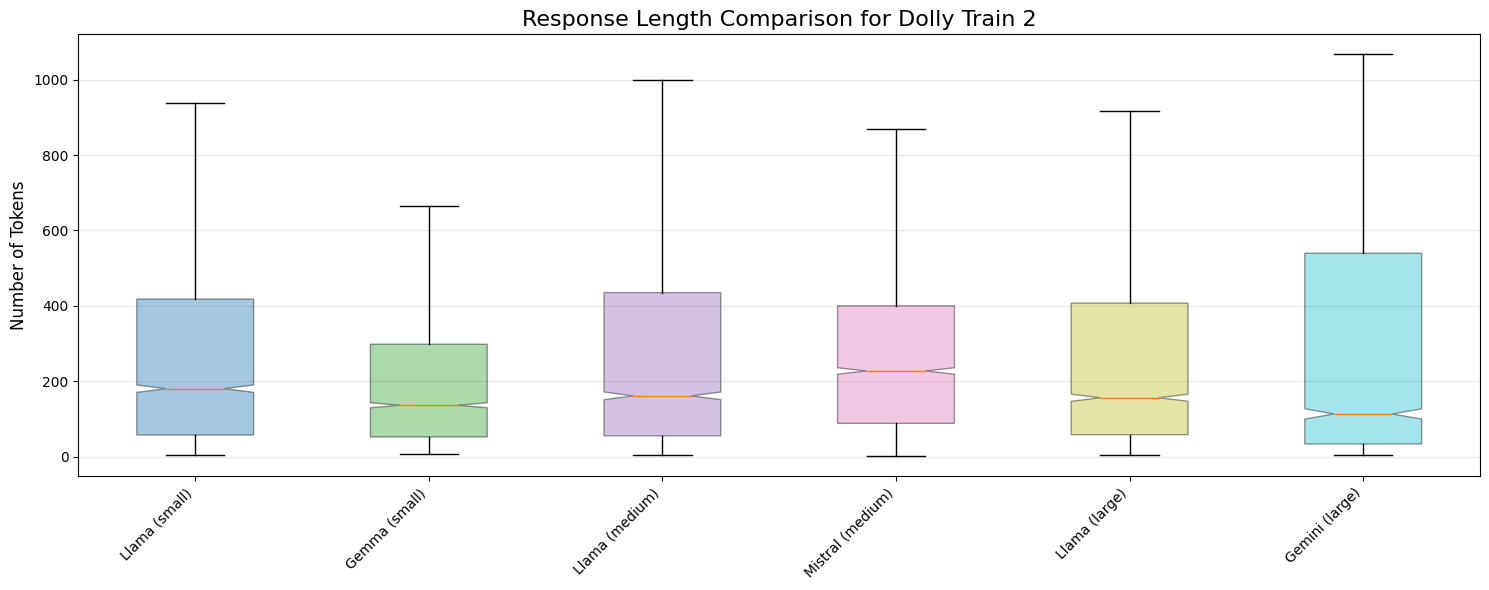

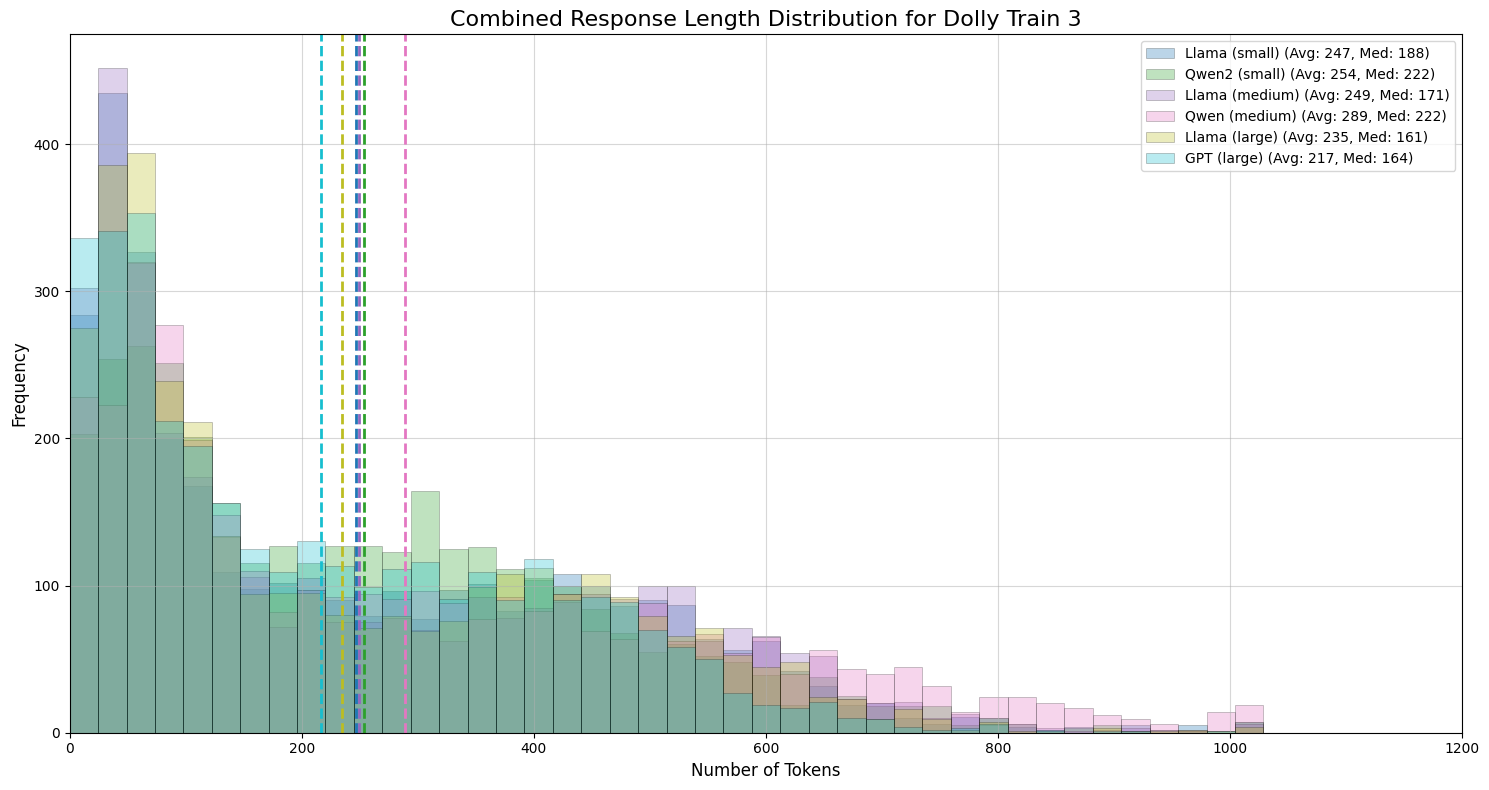

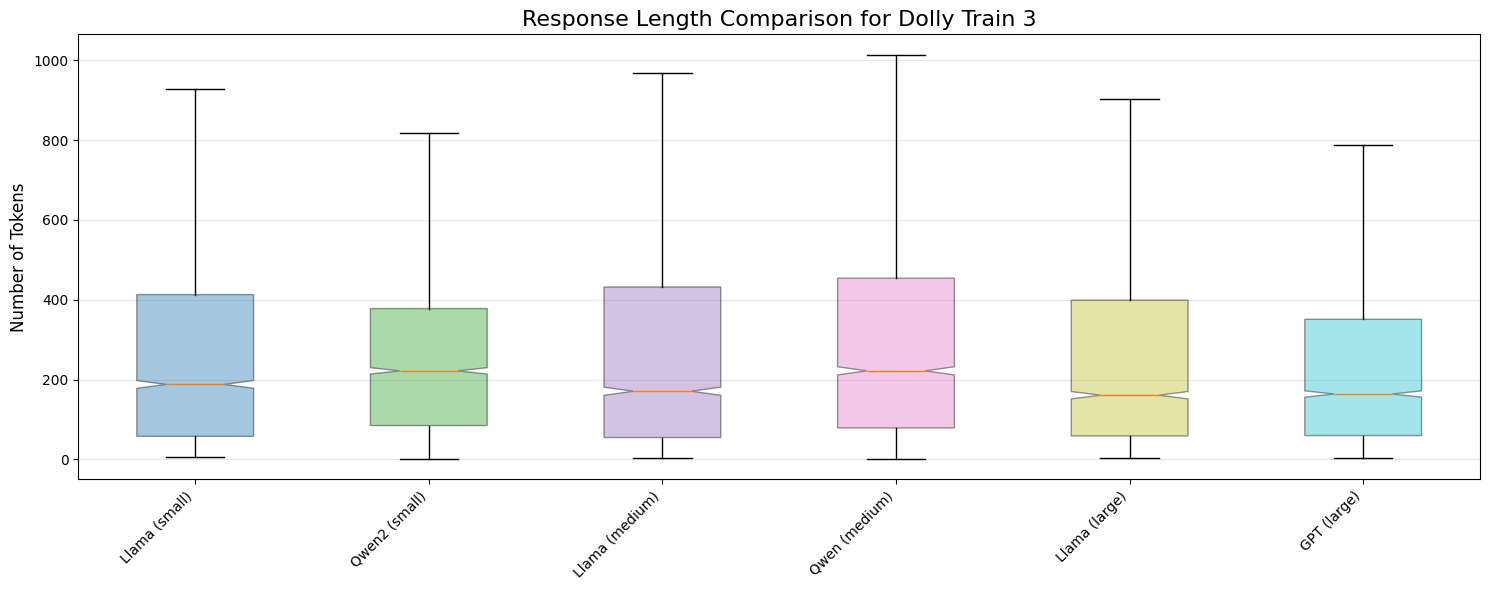

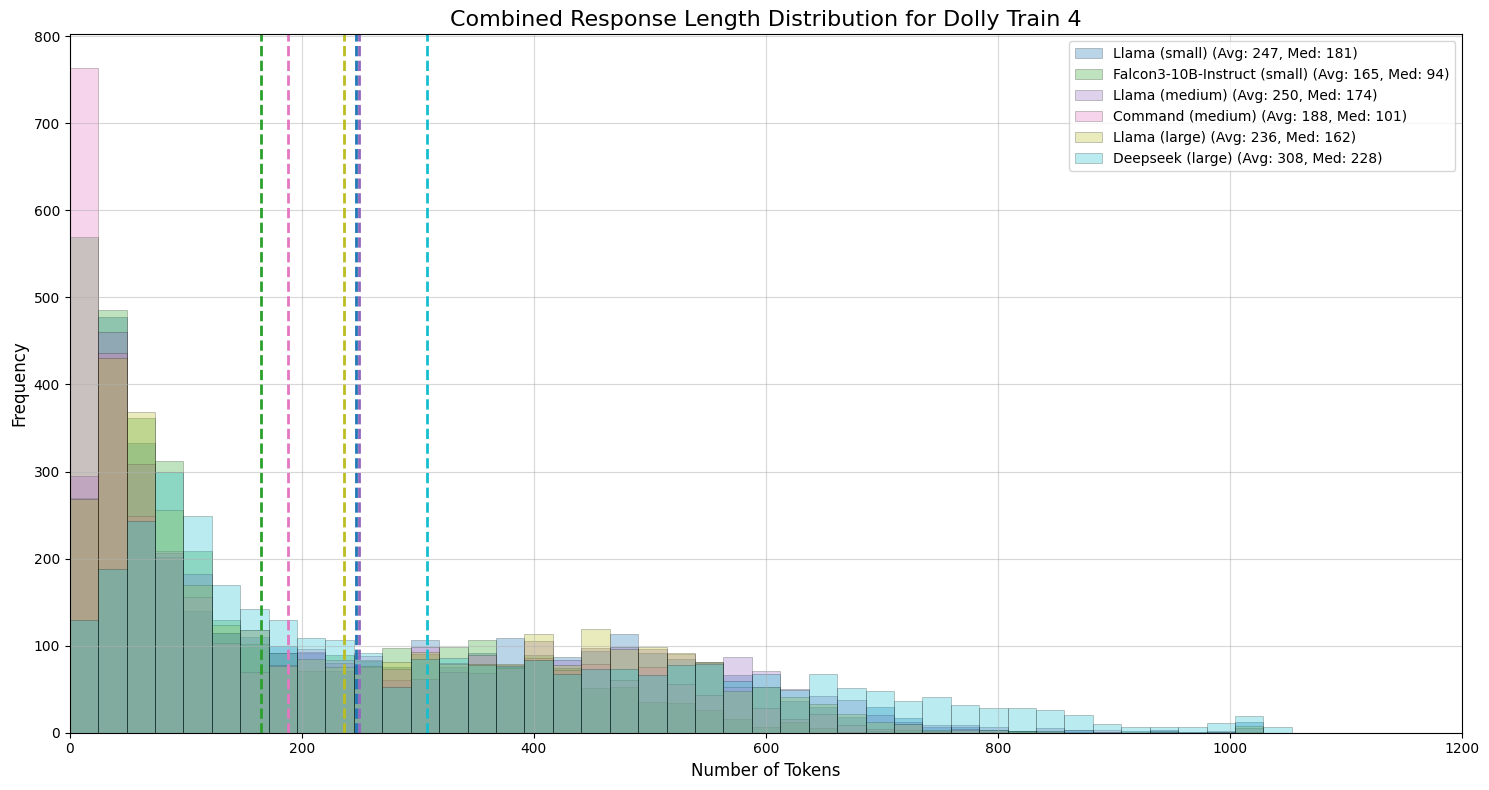

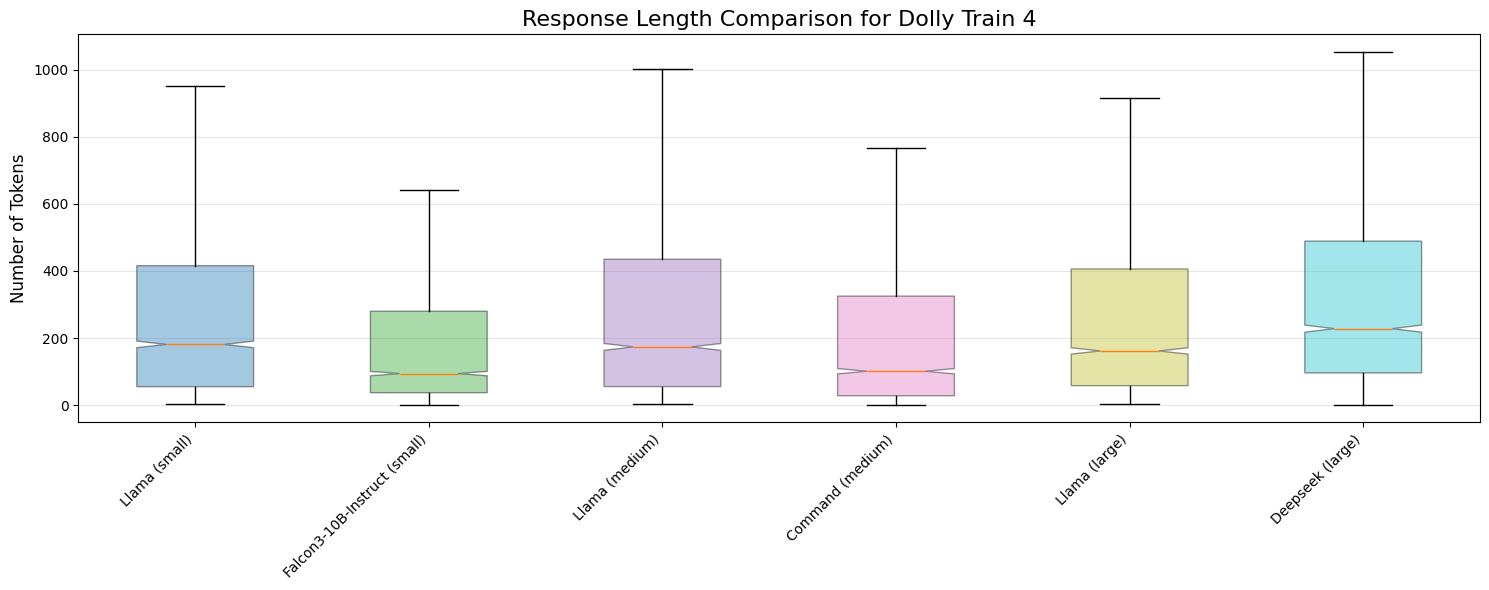

In [36]:
x_limit = 1200

# Create a function to plot combined histograms for each Dolly train version
def plot_combined_histograms(data_paths, model_sizes, enc, x_limit=x_limit):
    # Group paths by Dolly version
    version_groups = {}
    for path, size in zip(data_paths, model_sizes):
        model_name = path.split('/')[-1].split('.')[0]
        if 'dolly_train_' in model_name:
            # Extract version number
            version = model_name.split('dolly_train_')[1].split('_')[0]
            model_short_name = '_'.join(model_name.split('dolly_train_')[1].split('_')[1:])
            
            if version not in version_groups:
                version_groups[version] = []
            
            version_groups[version].append((path, model_short_name, size))
    
    # Plot combined histograms for each version
    for version, models in version_groups.items():
        plt.figure(figsize=(15, 8))
        
        # Create a dictionary to store response lengths for each model
        all_response_lengths = {}
        
        # Collect data for all models in this version
        for path, model_name, model_size in models:
            response_lengths = []
            with open(path, 'r') as f:
                for line in f:
                    data = json.loads(line)
                    response_key = [k for k in data.keys() if k.startswith('response_')][1]
                    response = data[response_key]
                    num_tokens = len(enc.encode(response))
                    response_lengths.append(num_tokens)
            
            # Store with a descriptive label
            all_response_lengths[f"{model_name} ({model_size})"] = response_lengths
        
        # Create histogram with alpha transparency to see overlaps
        bins = np.linspace(0, x_limit, 50)
        
        # Use different colors for each model
        colors = plt.cm.tab10(np.linspace(0, 1, len(all_response_lengths)))
        
        # Plot histograms with increased transparency
        for (model_label, lengths), color in zip(all_response_lengths.items(), colors):
            # Calculate statistics
            avg_len = sum(lengths)/len(lengths)
            median_len = sorted(lengths)[len(lengths)//2]
            
            plt.hist(lengths, bins=bins, alpha=0.3, label=f"{model_label} (Avg: {avg_len:.0f}, Med: {median_len:.0f})", 
                     color=color, edgecolor='black', linewidth=0.5)
        
        # Add a vertical line for each model's average
        for (model_label, lengths), color in zip(all_response_lengths.items(), colors):
            avg_len = sum(lengths)/len(lengths)
            plt.axvline(x=avg_len, color=color, linestyle='--', linewidth=2)
        
        plt.title(f'Combined Response Length Distribution for Dolly Train {version}', fontsize=16)
        plt.xlabel('Number of Tokens', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.grid(True, alpha=0.5)
        plt.xlim(0, x_limit)
        plt.legend(fontsize=10)
        plt.tight_layout()
        plt.show()
        
        # Create a box plot for easier comparison
        plt.figure(figsize=(15, 6))
        
        # Prepare data for boxplot
        data_for_boxplot = [lengths for _, lengths in all_response_lengths.items()]
        labels = [model_label for model_label, _ in all_response_lengths.items()]
        
        # Create boxplot
        boxplot = plt.boxplot(data_for_boxplot, patch_artist=True, notch=True, showfliers=False)
        
        # Color the boxes with increased transparency
        for box, color in zip(boxplot['boxes'], colors):
            box.set(facecolor=color, alpha=0.4)
        
        plt.title(f'Response Length Comparison for Dolly Train {version}', fontsize=16)
        plt.ylabel('Number of Tokens', fontsize=12)
        plt.grid(True, alpha=0.3, axis='y')
        plt.xticks(range(1, len(labels) + 1), labels, rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

# Call the function to plot combined histograms
plot_combined_histograms(data_paths, model_sizes, enc)


## Histograms with Gemini, gemma, human

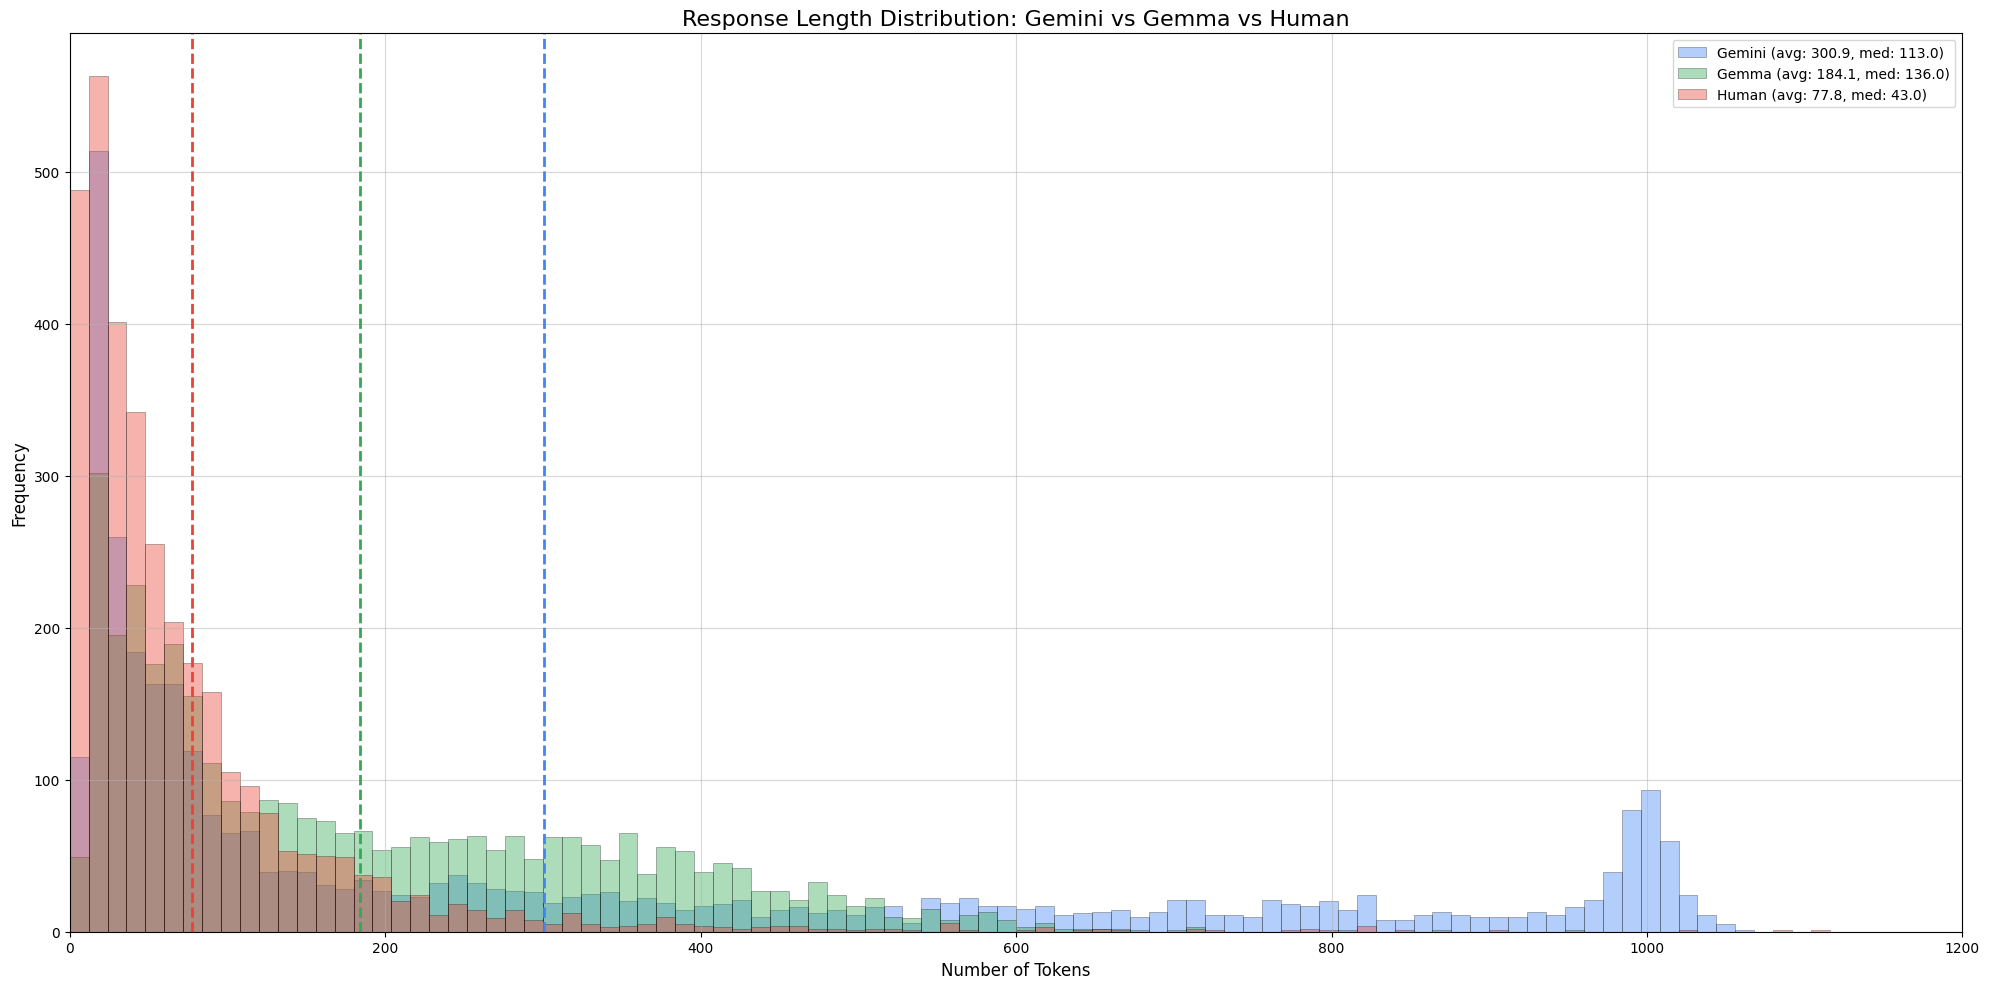

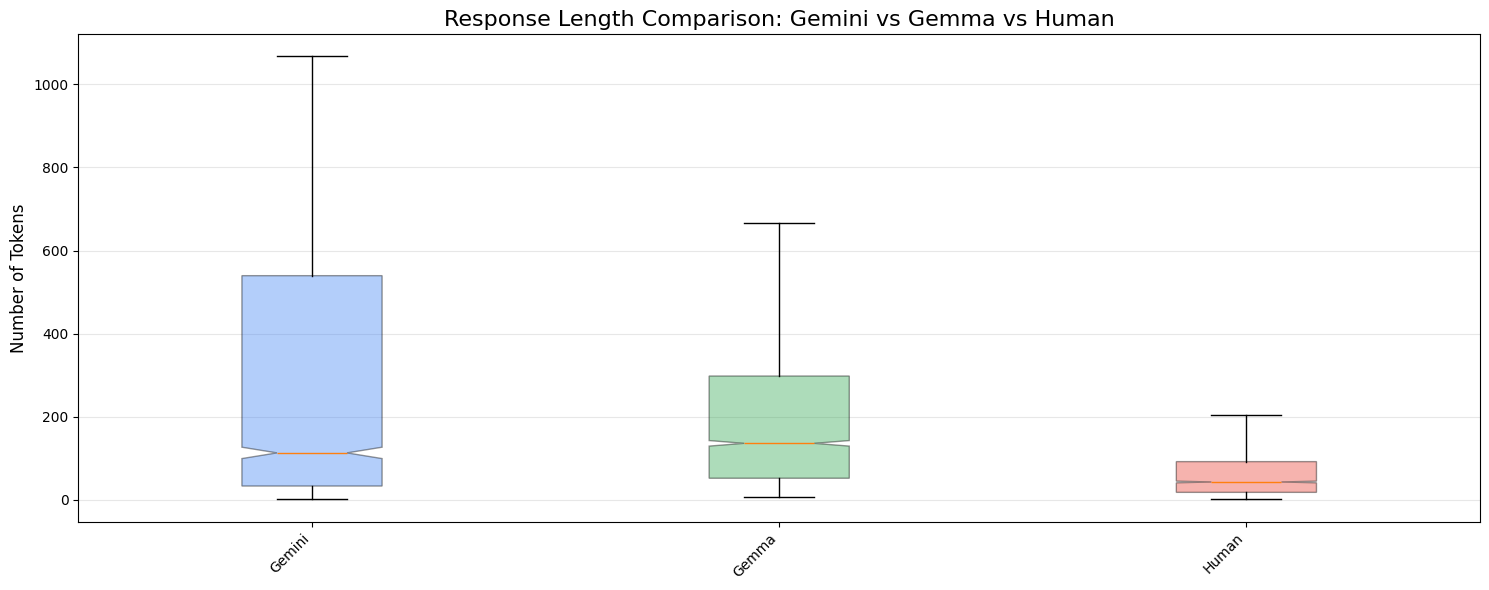

In [37]:
gemini_gemma_human_paths = [
    "../../Data/Finetuning/Augmented/Large/Other/dolly_train_2_Gemini.jsonl",
    "../../Data/Finetuning/Augmented/Small/Other/dolly_train_2_Gemma.jsonl",
    "../../Data/Finetuning/Dolly/dolly_train_2.jsonl"
]

# Define labels for the models
gemini_gemma_human_labels = ["Gemini", "Gemma", "Human"]

# Define colors for the models
gemini_gemma_human_colors = ['#4285F4', '#34A853', '#EA4335']  # Google colors for Gemini, Gemma, and red for Human

def plot_gemini_gemma_human_histograms(data_paths, model_labels, tokenizer, x_limit=1200, bins=100):
    """
    Plot combined histograms for Gemini, Gemma, and Human responses.
    
    Args:
        data_paths: List of paths to the data files
        model_labels: Labels for the models
        tokenizer: Tokenizer to use for counting tokens
        x_limit: Maximum x-axis limit
        bins: Number of bins for the histogram
    """
    all_response_lengths = {}
    
    # Process each data file
    for path, model_label in zip(data_paths, model_labels):
        response_lengths = []
        
        with open(path, 'r') as f:
            for line in f:
                data = json.loads(line)
                # Use response_human for human data, response_model for others
                if model_label == "Human":
                    response_key = "response_human"
                elif model_label == "Gemini":
                    response_key = "response_gemini-2.0-flash"
                elif model_label == "Gemma":
                    response_key = "response_gemma2-9b-it"
                
                response = data[response_key]
                num_tokens = len(tokenizer.encode(response))
                response_lengths.append(num_tokens)
        
        all_response_lengths[model_label] = response_lengths
    
    # Create combined histogram
    plt.figure(figsize=(20, 10))
    
    # Define common bin edges to ensure consistent bin width across datasets
    all_lengths = []
    for lengths in all_response_lengths.values():
        all_lengths.extend(lengths)
    
    # Create common bin edges from 0 to x_limit
    bin_edges = np.linspace(0, x_limit, bins + 1)
    
    for (model_label, lengths), color in zip(all_response_lengths.items(), gemini_gemma_human_colors):
        avg_len = np.mean(lengths)
        median_len = np.median(lengths)
        plt.hist(lengths, bins=bin_edges, alpha=0.4, label=f'{model_label} (avg: {avg_len:.1f}, med: {median_len:.1f})', 
                 color=color, edgecolor='black', linewidth=0.5)
        plt.axvline(x=avg_len, color=color, linestyle='--', linewidth=2)
    
    plt.title('Response Length Distribution: Gemini vs Gemma vs Human', fontsize=16)
    plt.xlabel('Number of Tokens', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(True, alpha=0.5)
    plt.xlim(0, x_limit)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
    
    # Create a box plot for easier comparison
    plt.figure(figsize=(15, 6))
    
    # Prepare data for boxplot
    data_for_boxplot = [lengths for _, lengths in all_response_lengths.items()]
    labels = [model_label for model_label, _ in all_response_lengths.items()]
    
    # Create boxplot
    boxplot = plt.boxplot(data_for_boxplot, patch_artist=True, notch=True, showfliers=False)
    
    # Color the boxes with increased transparency
    for box, color in zip(boxplot['boxes'], gemini_gemma_human_colors):
        box.set(facecolor=color, alpha=0.4)
    
    plt.title('Response Length Comparison: Gemini vs Gemma vs Human', fontsize=16)
    plt.ylabel('Number of Tokens', fontsize=12)
    plt.grid(True, alpha=0.3, axis='y')
    plt.xticks(range(1, len(labels) + 1), labels, rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Call the function to plot combined histograms for Gemini, Gemma, and Human
plot_gemini_gemma_human_histograms(gemini_gemma_human_paths, gemini_gemma_human_labels, enc)


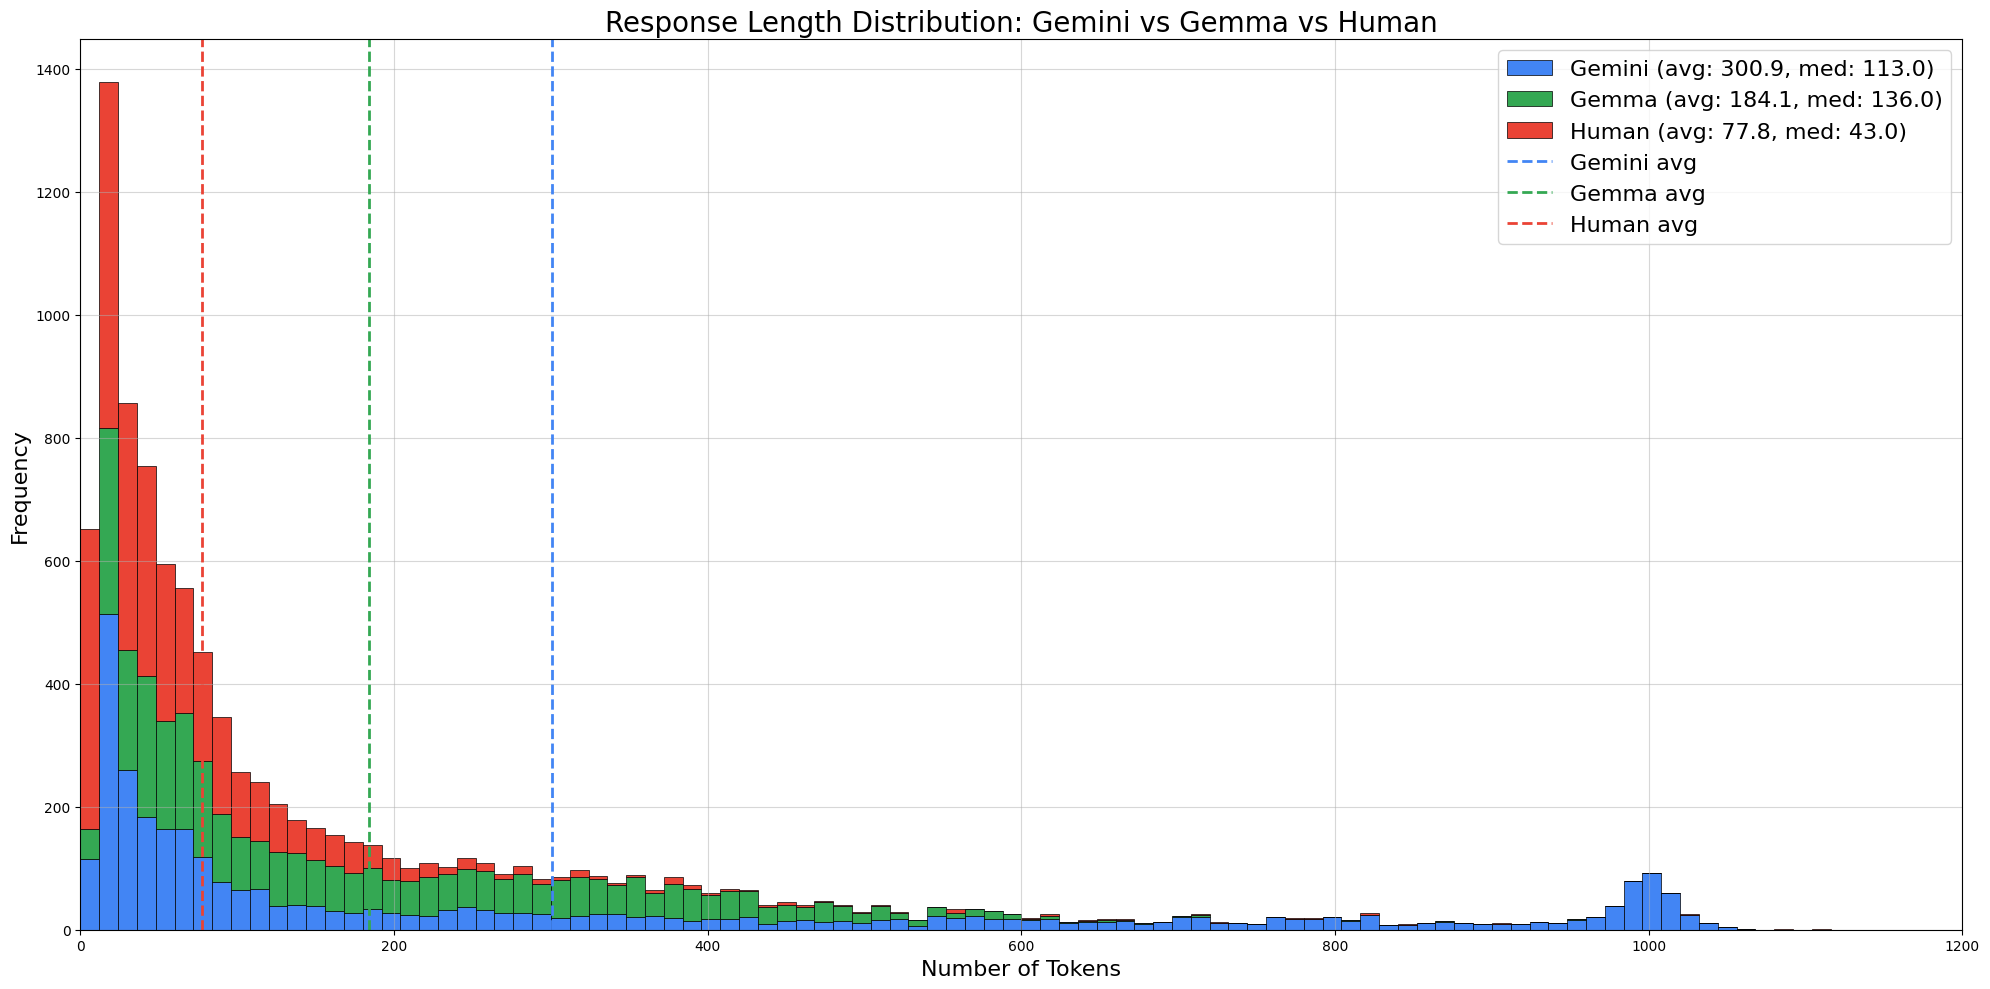

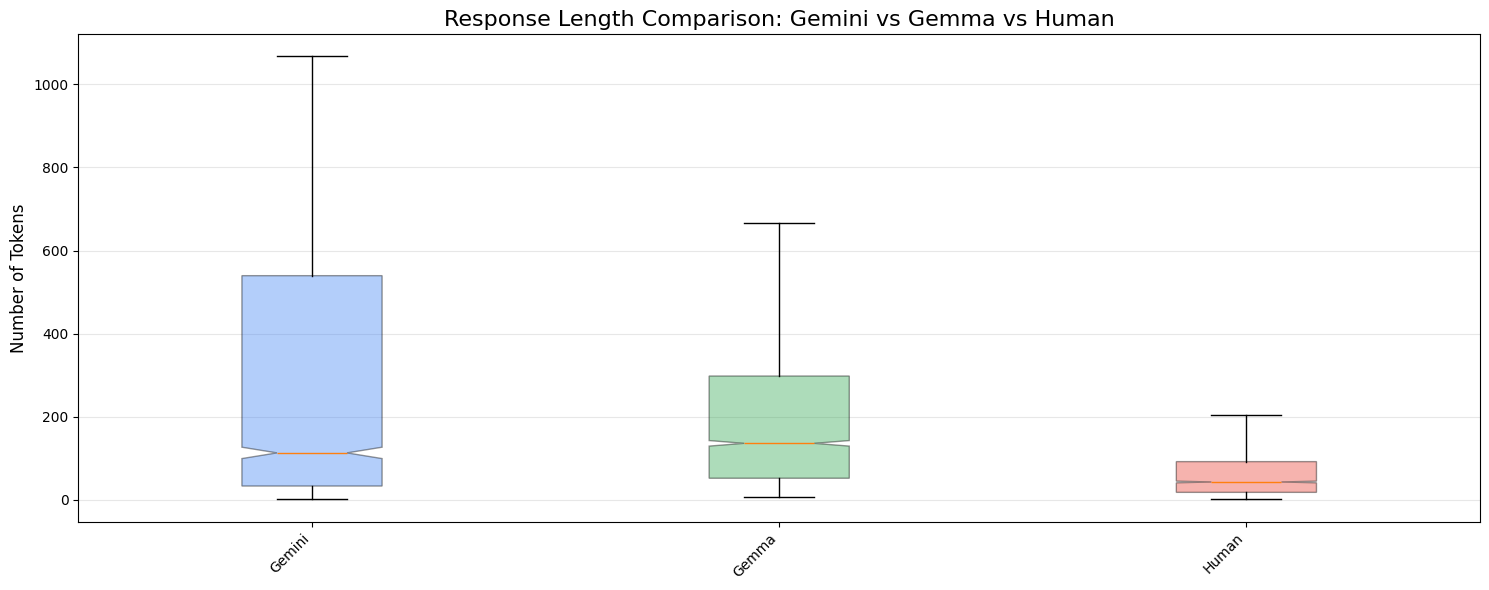

In [44]:
gemini_gemma_human_paths = [
    "../../Data/Finetuning/Augmented/Large/Other/dolly_train_2_Gemini.jsonl",
    "../../Data/Finetuning/Augmented/Small/Other/dolly_train_2_Gemma.jsonl",
    "../../Data/Finetuning/Dolly/dolly_train_2.jsonl"
]

# Define labels for the models
gemini_gemma_human_labels = ["Gemini", "Gemma", "Human"]

# Define colors for the models
gemini_gemma_human_colors = ['#4285F4', '#34A853', '#EA4335']  # Google colors for Gemini, Gemma, and red for Human

def plot_stacked_histogram(data_paths, model_labels, tokenizer, x_limit=1200, bins=100):
    """
    Plot stacked histograms for Gemini, Gemma, and Human responses.
    
    Args:
        data_paths: List of paths to the data files
        model_labels: Labels for the models
        tokenizer: Tokenizer to use for counting tokens
        x_limit: Maximum x-axis limit
        bins: Number of bins for the histogram
    """
    all_response_lengths = {}
    
    # Process each data file
    for path, model_label in zip(data_paths, model_labels):
        response_lengths = []
        
        with open(path, 'r') as f:
            for line in f:
                data = json.loads(line)
                # Use response_human for human data, response_model for others
                if model_label == "Human":
                    response_key = "response_human"
                elif model_label == "Gemini":
                    response_key = "response_gemini-2.0-flash"
                elif model_label == "Gemma":
                    response_key = "response_gemma2-9b-it"
                
                response = data[response_key]
                num_tokens = len(tokenizer.encode(response))
                response_lengths.append(num_tokens)
        
        all_response_lengths[model_label] = response_lengths
    
    # Create stacked histogram
    plt.figure(figsize=(20, 10))
    
    # Define common bin edges to ensure consistent bin width across datasets
    all_lengths = []
    for lengths in all_response_lengths.values():
        all_lengths.extend(lengths)
    
    # Create common bin edges from 0 to x_limit
    bin_edges = np.linspace(0, x_limit, bins + 1)
    
    # Calculate histograms for each model
    hist_data = []
    labels = []
    avgs = []
    medians = []
    
    for model_label, lengths in all_response_lengths.items():
        hist, _ = np.histogram(lengths, bins=bin_edges)
        hist_data.append(hist)
        labels.append(model_label)
        avgs.append(np.mean(lengths))
        medians.append(np.median(lengths))
    
    # Plot stacked histogram
    plt.hist(
        [all_response_lengths[label] for label in model_labels],
        bins=bin_edges,
        stacked=True,
        label=[f'{label} (avg: {avg:.1f}, med: {med:.1f})' 
               for label, avg, med in zip(model_labels, avgs, medians)],
        color=gemini_gemma_human_colors,
        edgecolor='black',
        linewidth=0.5
    )
    
    # Add vertical lines for averages
    for avg, color, label in zip(avgs, gemini_gemma_human_colors, model_labels):
        plt.axvline(x=avg, color=color, linestyle='--', linewidth=2, 
                   label=f'{label} avg')
    
    plt.title('Response Length Distribution: Gemini vs Gemma vs Human', fontsize=20)
    plt.xlabel('Number of Tokens', fontsize=16)
    plt.ylabel('Frequency', fontsize=16)
    plt.grid(True, alpha=0.5)
    plt.xlim(0, x_limit)
    plt.legend(fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Create a box plot for easier comparison
    plt.figure(figsize=(15, 6))
    
    # Prepare data for boxplot
    data_for_boxplot = [lengths for _, lengths in all_response_lengths.items()]
    labels = [model_label for model_label, _ in all_response_lengths.items()]
    
    # Create boxplot
    boxplot = plt.boxplot(data_for_boxplot, patch_artist=True, notch=True, showfliers=False)
    
    # Color the boxes with increased transparency
    for box, color in zip(boxplot['boxes'], gemini_gemma_human_colors):
        box.set(facecolor=color, alpha=0.4)
    
    plt.title('Response Length Comparison: Gemini vs Gemma vs Human', fontsize=16)
    plt.ylabel('Number of Tokens', fontsize=12)
    plt.grid(True, alpha=0.3, axis='y')
    plt.xticks(range(1, len(labels) + 1), labels, rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Call the function to plot stacked histogram
plot_stacked_histogram(gemini_gemma_human_paths, gemini_gemma_human_labels, enc)


## Command, deepseek, human

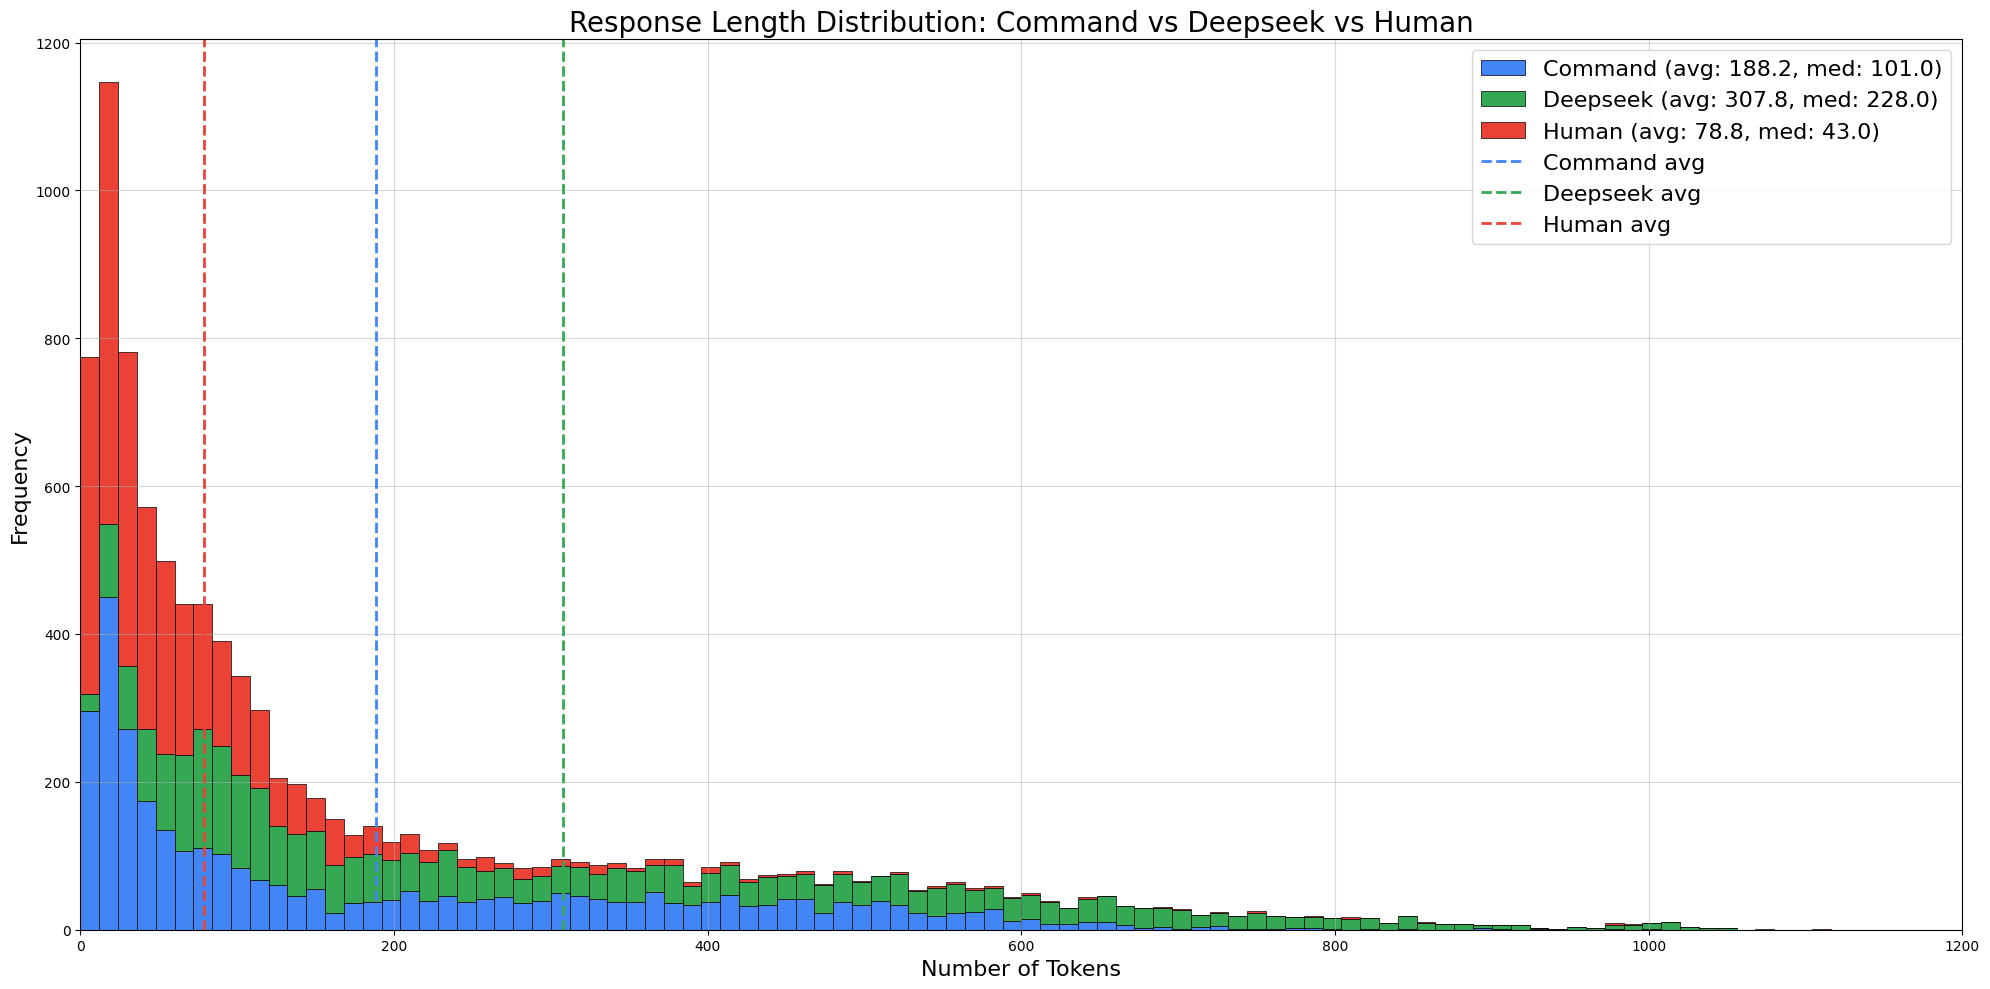

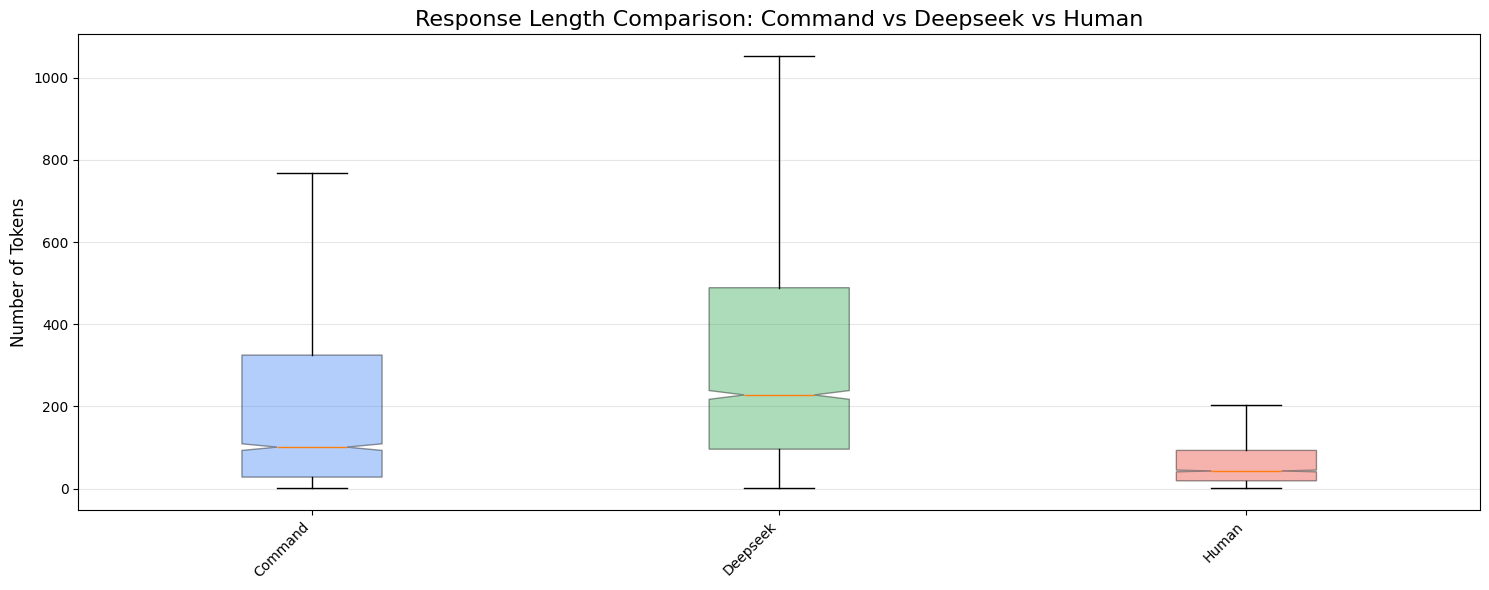

In [45]:
command_deepseek_human_paths = [
    "../../Data/Finetuning/Augmented/Medium/Other/dolly_train_4_Command.jsonl",
    "../../Data/Finetuning/Augmented/Large/Other/dolly_train_4_Deepseek.jsonl",
    "../../Data/Finetuning/Dolly/dolly_train_4.jsonl"
]

# Define labels for the models
command_deepseek_human_labels = ["Command", "Deepseek", "Human"]

# Define colors for the models
command_deepseek_human_colors = ['#4285F4', '#34A853', '#EA4335']  # Colors for Command, Deepseek, and red for Human

def plot_stacked_histogram(data_paths, model_labels, tokenizer, x_limit=1200, bins=100):
    """
    Plot stacked histograms for Gemini, Gemma, and Human responses.
    
    Args:
        data_paths: List of paths to the data files
        model_labels: Labels for the models
        tokenizer: Tokenizer to use for counting tokens
        x_limit: Maximum x-axis limit
        bins: Number of bins for the histogram
    """
    all_response_lengths = {}
    
    # Process each data file
    for path, model_label in zip(data_paths, model_labels):
        response_lengths = []
        
        with open(path, 'r') as f:
            for line in f:
                data = json.loads(line)
                # Use response_human for human data, response_model for others
                if model_label == "Human":
                    response_key = "response_human"
                elif model_label == "Command":
                    response_key = "response_command-r-plus"
                elif model_label == "Deepseek":
                    response_key = "response_deepseek-ai/DeepSeek-V3"
                
                response = data[response_key]
                num_tokens = len(tokenizer.encode(response))
                response_lengths.append(num_tokens)
        
        all_response_lengths[model_label] = response_lengths
    
    # Create stacked histogram
    plt.figure(figsize=(20, 10))
    
    # Define common bin edges to ensure consistent bin width across datasets
    all_lengths = []
    for lengths in all_response_lengths.values():
        all_lengths.extend(lengths)
    
    # Create common bin edges from 0 to x_limit
    bin_edges = np.linspace(0, x_limit, bins + 1)
    
    # Calculate histograms for each model
    hist_data = []
    labels = []
    avgs = []
    medians = []
    
    for model_label, lengths in all_response_lengths.items():
        hist, _ = np.histogram(lengths, bins=bin_edges)
        hist_data.append(hist)
        labels.append(model_label)
        avgs.append(np.mean(lengths))
        medians.append(np.median(lengths))
    
    # Plot stacked histogram
    plt.hist(
        [all_response_lengths[label] for label in model_labels],
        bins=bin_edges,
        stacked=True,
        label=[f'{label} (avg: {avg:.1f}, med: {med:.1f})' 
               for label, avg, med in zip(model_labels, avgs, medians)],
        color=gemini_gemma_human_colors,
        edgecolor='black',
        linewidth=0.5
    )
    
    # Add vertical lines for averages
    for avg, color, label in zip(avgs, gemini_gemma_human_colors, model_labels):
        plt.axvline(x=avg, color=color, linestyle='--', linewidth=2, 
                   label=f'{label} avg')
    
    plt.title('Response Length Distribution: Command vs Deepseek vs Human', fontsize=20)
    plt.xlabel('Number of Tokens', fontsize=16)
    plt.ylabel('Frequency', fontsize=16)
    plt.grid(True, alpha=0.5)
    plt.xlim(0, x_limit)
    plt.legend(fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Create a box plot for easier comparison
    plt.figure(figsize=(15, 6))
    
    # Prepare data for boxplot
    data_for_boxplot = [lengths for _, lengths in all_response_lengths.items()]
    labels = [model_label for model_label, _ in all_response_lengths.items()]
    
    # Create boxplot
    boxplot = plt.boxplot(data_for_boxplot, patch_artist=True, notch=True, showfliers=False)
    
    # Color the boxes with increased transparency
    for box, color in zip(boxplot['boxes'], gemini_gemma_human_colors):
        box.set(facecolor=color, alpha=0.4)
    
    plt.title('Response Length Comparison: Command vs Deepseek vs Human', fontsize=16)
    plt.ylabel('Number of Tokens', fontsize=12)
    plt.grid(True, alpha=0.3, axis='y')
    plt.xticks(range(1, len(labels) + 1), labels, rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Call the function to plot stacked histogram
plot_stacked_histogram(command_deepseek_human_paths, command_deepseek_human_labels, enc)


## Statistics

In [46]:
# Calculate number of responses over 1000 tokens
print("\nResponses over 1000 tokens:")
print("-" * 80)
for path in data_paths:
    long_responses = 0
    total_responses = 0
    
    with open(path, 'r') as f:
        for line in f:
            data = json.loads(line)
            response_key = [k for k in data.keys() if k.startswith('response_')][1]
            response = data[response_key]
            num_tokens = len(enc.encode(response))
            if num_tokens > 1000:
                long_responses += 1
            total_responses += 1
    
    model_name = path.split('/')[-1].split('.')[0]
    percentage = (long_responses / total_responses) * 100
    print(f"{model_name}:")
    print(f"Number of responses > 1000 tokens: {long_responses} ({percentage:.1f}%)")
    print(f"Total responses: {total_responses}")
    print("-" * 80)



Responses over 1000 tokens:
--------------------------------------------------------------------------------
dolly_train_1_Llama:
Number of responses > 1000 tokens: 14 (0.4%)
Total responses: 3377
--------------------------------------------------------------------------------
dolly_train_2_Llama:
Number of responses > 1000 tokens: 12 (0.4%)
Total responses: 3377
--------------------------------------------------------------------------------
dolly_train_3_Llama:
Number of responses > 1000 tokens: 7 (0.2%)
Total responses: 3377
--------------------------------------------------------------------------------
dolly_train_4_Llama:
Number of responses > 1000 tokens: 12 (0.4%)
Total responses: 3378
--------------------------------------------------------------------------------
dolly_train_2_Gemma:
Number of responses > 1000 tokens: 0 (0.0%)
Total responses: 3377
--------------------------------------------------------------------------------
dolly_train_3_Qwen2:
Number of responses > 1000